# Generative AI untuk Vision dan Text menggunakan PyTorch
### Implementasi: Autoencoder, VAE, GAN (Vision) + LSTM, Transformer (Text)

---
| | |
|---|---|
| **Nama** | Ikhlasul Amal |
| **NIM** | 2546000066 |
| **Kelas** | Pembelajaran Mesin - B |
| **Dataset Vision** | MNIST (28×28 grayscale, 60.000 train / 10.000 test) |
| **Dataset Text** | Kumpulan kalimat Bahasa Indonesia (~100 kalimat) |
| **Model Vision** | Autoencoder, Variational Autoencoder (VAE), GAN |
| **Model Text** | LSTM Text Generator, Mini GPT (Transformer) |

---

# ─────────────────────────────────────────
# BAGIAN 1 — IMPORT LIBRARY
# ─────────────────────────────────────────

In [2]:
# ================================================================
# BAGIAN 1: IMPORT LIBRARY
# ================================================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import MNIST

import numpy as np
import matplotlib.pyplot as plt
import time
import random

print("✅ Semua library berhasil diimport!")
print(f"   PyTorch versi : {torch.__version__}")
print(f"   Torchvision   : {torchvision.__version__}")

✅ Semua library berhasil diimport!
   PyTorch versi : 2.9.1+cpu
   Torchvision   : 0.24.1+cpu


# ─────────────────────────────────────────
# BAGIAN 2 — SET DEVICE
# ─────────────────────────────────────────

In [3]:
# ================================================================
# BAGIAN 2: SET DEVICE (GPU / CPU)
# ================================================================

# Gunakan GPU jika tersedia, fallback ke CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device yang digunakan : {device}")
if device == "cuda":
    print(f"Nama GPU              : {torch.cuda.get_device_name(0)}")

# Set seed untuk reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if device == "cuda":
    torch.cuda.manual_seed(SEED)

# ---- Fungsi utilitas ----
def count_parameters(model):
    """Hitung jumlah parameter yang bisa dilatih."""
    total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Jumlah parameter trainable: {total:,}")
    return total

def timer(start, label=""):
    """Hitung dan cetak waktu training."""
    elapsed = time.time() - start
    print(f"  ⏱ Waktu training {label}: {elapsed:.1f} detik ({elapsed/60:.1f} menit)")

Device yang digunakan : cpu


---
# BAGIAN VISION: GENERATIVE AI UNTUK GAMBAR
---

# ─────────────────────────────────────────
# BAGIAN 3 — LOAD DATASET VISION
# ─────────────────────────────────────────

✅ Dataset MNIST berhasil di-download!
   Training : 60,000 gambar
   Testing  : 10,000 gambar
   Ukuran gambar: torch.Size([1, 28, 28])  (Channel × H × W)
   Jumlah kelas : 10 (digit 0–9)
   Range nilai  : [0.00, 1.00]  (belum dinormalisasi)


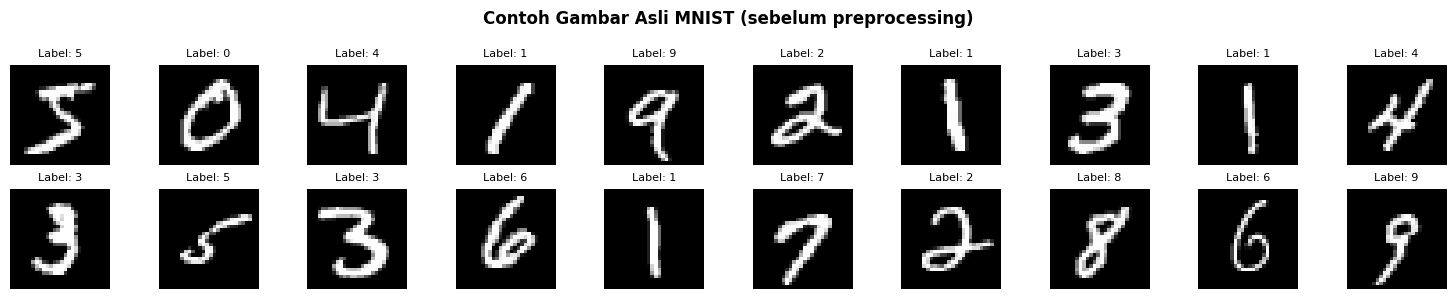

In [4]:
# ================================================================
# BAGIAN 3: LOAD DATASET VISION — MNIST
# Dataset: 70.000 gambar digit 0-9, ukuran 28×28 piksel, grayscale
# Sumber  : http://yann.lecun.com/exdb/mnist/
# ================================================================

from torchvision.datasets import MNIST
import torchvision.transforms as transforms

# Download dan load dataset TANPA transformasi dulu
# (transformasi dilakukan di bagian preprocessing)
raw_train = MNIST(root='./data', train=True,  download=True, transform=transforms.ToTensor())
raw_test  = MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

print("✅ Dataset MNIST berhasil di-download!")
print(f"   Training : {len(raw_train):,} gambar")
print(f"   Testing  : {len(raw_test):,} gambar")
print(f"   Ukuran gambar: {raw_train[0][0].shape}  (Channel × H × W)")
print(f"   Jumlah kelas : 10 (digit 0–9)")
print(f"   Range nilai  : [{raw_train[0][0].min():.2f}, {raw_train[0][0].max():.2f}]  (belum dinormalisasi)")

# Tampilkan beberapa contoh gambar asli
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
fig.suptitle("Contoh Gambar Asli MNIST (sebelum preprocessing)",
             fontsize=12, fontweight='bold')
for i in range(20):
    ax = axes[i//10][i%10]
    ax.imshow(raw_train[i][0].squeeze(), cmap='gray')
    ax.set_title(f"Label: {raw_train[i][1]}", fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig('01_original_images.png', dpi=100, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────
# BAGIAN 4 — PREPROCESSING DATASET VISION
# ─────────────────────────────────────────

✅ Preprocessing selesai!
   Shape satu batch : torch.Size([128, 1, 28, 28])  (Batch × C × H × W)
   Range setelah normalisasi: [-1.00, 1.00]
   Jumlah batch per epoch   : 469


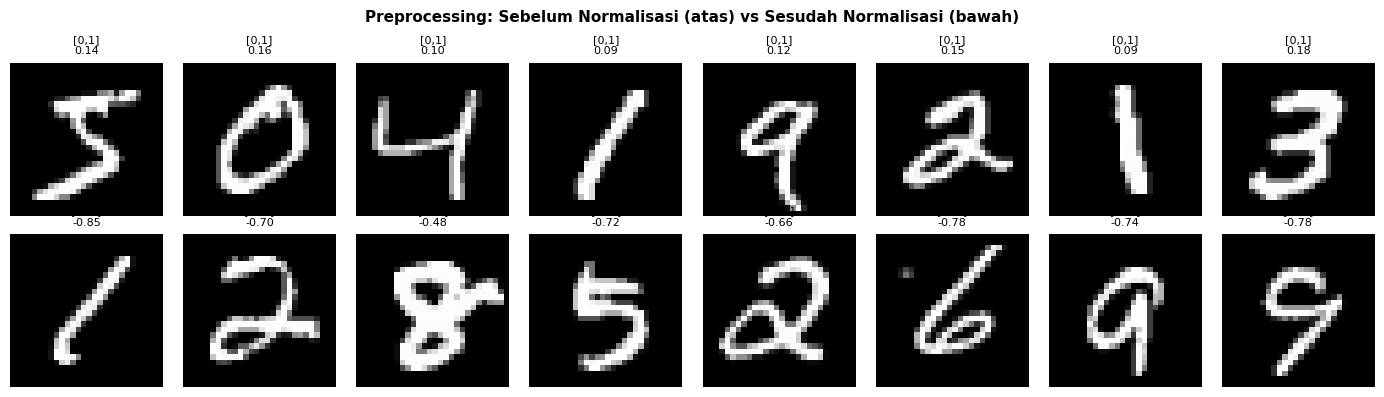

In [5]:
# ================================================================
# BAGIAN 4: PREPROCESSING DATASET VISION
# Langkah:
#   1. ToTensor()      — ubah PIL Image (0–255) ke Tensor (0.0–1.0)
#   2. Normalize(0.5)  — ubah range [0,1] → [-1,1]
#      Rumus: x_norm = (x - 0.5) / 0.5
#      Mengapa [-1,1]? Karena GAN menggunakan aktivasi Tanh di output
#      yang juga menghasilkan nilai [-1,1]
# ================================================================

transform_vision = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))  # [0,1] → [-1,1]
])

# Terapkan transformasi
train_dataset = MNIST(root='./data', train=True,  download=True, transform=transform_vision)
test_dataset  = MNIST(root='./data', train=False, download=True, transform=transform_vision)

# Buat DataLoader
BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Verifikasi hasil preprocessing
sample_imgs, sample_labels = next(iter(train_loader))
print("✅ Preprocessing selesai!")
print(f"   Shape satu batch : {sample_imgs.shape}  (Batch × C × H × W)")
print(f"   Range setelah normalisasi: [{sample_imgs.min():.2f}, {sample_imgs.max():.2f}]")
print(f"   Jumlah batch per epoch   : {len(train_loader)}")

# Visualisasi sebelum vs sesudah normalisasi
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle("Preprocessing: Sebelum Normalisasi (atas) vs Sesudah Normalisasi (bawah)",
             fontsize=11, fontweight='bold')
raw_imgs = [raw_train[i][0].squeeze().numpy() for i in range(8)]
norm_imgs = [(sample_imgs[i].squeeze().numpy()) for i in range(8)]  # [-1,1]

for i in range(8):
    axes[0,i].imshow(raw_imgs[i], cmap='gray', vmin=0, vmax=1)
    axes[0,i].set_title(f"[0,1]\n{raw_imgs[i].mean():.2f}", fontsize=8)
    axes[0,i].axis('off')
    axes[1,i].imshow(norm_imgs[i], cmap='gray', vmin=-1, vmax=1)
    axes[1,i].set_title(f"[-1,1]\n{norm_imgs[i].mean():.2f}", fontsize=8)
    axes[1,i].axis('off')
plt.tight_layout()
plt.savefig('02_preprocessing.png', dpi=100, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────
# BAGIAN 5 — DEFINISI MODEL GENERATIF VISION
# ─────────────────────────────────────────

In [6]:
# ================================================================
# BAGIAN 5: DEFINISI MODEL GENERATIF VISION
# Model yang diimplementasikan:
#   A. Autoencoder (AE)
#   B. Variational Autoencoder (VAE)
#   C. Generative Adversarial Network (GAN)
# ================================================================

# ---------------------------------------------------------------
# MODEL A: AUTOENCODER
# Alur: x → Encoder → z (latent) → Decoder → x̂
# ---------------------------------------------------------------
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        # Encoder: f_θ(x)  →  z
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, latent_dim)          # output: z ∈ R^latent_dim
        )
        # Decoder: g_φ(z)  →  x̂
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256),        nn.ReLU(),
            nn.Linear(256, 784),        nn.Tanh(),       # output ∈ [-1,1]
            nn.Unflatten(1, (1, 28, 28))
        )
    def forward(self, x):
        z     = self.encoder(x)       # z = f_θ(x)
        x_hat = self.decoder(z)       # x̂ = g_φ(z)
        return x_hat, z

# ---------------------------------------------------------------
# MODEL B: VARIATIONAL AUTOENCODER (VAE)
# Alur: x → Encoder → (μ, log σ²) → reparameterize → z → Decoder → x̂
# ---------------------------------------------------------------
class VAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.latent_dim = latent_dim
        # Encoder bersama
        self.enc_shared = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU()
        )
        # Dua head: μ dan log σ²
        self.fc_mu     = nn.Linear(128, latent_dim)   # μ
        self.fc_logvar = nn.Linear(128, latent_dim)   # log σ²
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256),        nn.ReLU(),
            nn.Linear(256, 784),        nn.Tanh(),
            nn.Unflatten(1, (1, 28, 28))
        )
    def encode(self, x):
        h      = self.enc_shared(x)
        mu     = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    def reparameterize(self, mu, logvar):
        # Trick reparameterisasi: z = μ + σ·ε,  ε ~ N(0,I)
        if self.training:
            std = torch.exp(0.5 * logvar)    # σ = exp(0.5 · log σ²)
            eps = torch.randn_like(std)       # ε ~ N(0, I)
            return mu + std * eps
        return mu
    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = self.reparameterize(mu, logvar)
        x_hat      = self.decoder(z)
        return x_hat, mu, logvar

def vae_loss_fn(x_hat, x, mu, logvar, beta=0.5):
    # Reconstruction loss: ||x - x̂||²
    recon = F.mse_loss(x_hat, x, reduction='mean')
    # KL Divergence: -0.5 · Σ(1 + log σ² - μ² - σ²)
    kl    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta * kl, recon, kl

# ---------------------------------------------------------------
# MODEL C: GAN (Generator + Discriminator)
# Alur G: z (noise) → Generator → gambar palsu
# Alur D: gambar (asli/palsu) → Discriminator → P(asli)
# ---------------------------------------------------------------
NOISE_DIM = 100

class Generator(nn.Module):
    def __init__(self, noise_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, 256), nn.LeakyReLU(0.2), nn.BatchNorm1d(256),
            nn.Linear(256, 512),       nn.LeakyReLU(0.2), nn.BatchNorm1d(512),
            nn.Linear(512, 784),       nn.Tanh(),
            nn.Unflatten(1, (1, 28, 28))
        )
    def forward(self, z):
        return self.model(z)          # G(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(256, 1),   nn.Sigmoid()       # output: P(gambar asli)
        )
    def forward(self, x):
        return self.model(x)          # D(x)

# Inisialisasi semua model
LATENT_DIM_AE  = 32
LATENT_DIM_VAE = 16

autoencoder   = Autoencoder(latent_dim=LATENT_DIM_AE).to(device)
vae           = VAE(latent_dim=LATENT_DIM_VAE).to(device)
generator     = Generator(noise_dim=NOISE_DIM).to(device)
discriminator = Discriminator().to(device)

print("✅ Semua model berhasil dibuat!")
print("\nAutoencoder:"); count_parameters(autoencoder)
print("VAE:");          count_parameters(vae)
print("Generator:");    count_parameters(generator)
print("Discriminator:");count_parameters(discriminator)

✅ Semua model berhasil dibuat!

Autoencoder:
  Jumlah parameter trainable: 476,720
VAE:
  Jumlah parameter trainable: 474,672
Generator:
  Jumlah parameter trainable: 561,168
Discriminator:
  Jumlah parameter trainable: 533,505


533505

# ─────────────────────────────────────────
# BAGIAN 6 — PENJELASAN RUMUS MODEL VISION
# ─────────────────────────────────────────

## BAGIAN 6: Penjelasan Rumus Model Vision

---
### 🔵 A. Autoencoder

| Rumus | Arti | Kode PyTorch |
|---|---|---|
| `z = f_θ(x)` | Encoder: kompres gambar x ke latent vector z | `self.encoder(x)` |
| `x̂ = g_φ(z)` | Decoder: rekonstruksi gambar dari z | `self.decoder(z)` |
| `L = ‖x − x̂‖²` | MSE Loss antara asli dan rekonstruksi | `nn.MSELoss()` |

**Penjelasan:** Encoder memampatkan gambar 784-dimensi menjadi latent vector z berdimensi kecil. Decoder mencoba merekonstruksi gambar asli dari z. Loss mengukur seberapa jauh hasil rekonstruksi dari aslinya.

---
### 🟣 B. Variational Autoencoder (VAE)

| Rumus | Arti | Kode PyTorch |
|---|---|---|
| `q_φ(z|x)` | Distribusi posterior latent dari encoder | `self.encode(x)` |
| `z = μ + σ·ε` | Reparameterization trick (ε ~ N(0,I)) | `mu + std * eps` |
| `L_KL = D_KL(q‖p)` | KL Divergence agar z ~ N(0,I) | `-0.5*(1+logvar-mu²-exp(logvar))` |
| `L = L_recon + β·L_KL` | Total ELBO loss | `recon + beta * kl` |

**Penjelasan:** VAE mempelajari distribusi q_φ(z|x) ≈ N(μ, σ²). Reparameterization trick memungkinkan gradient mengalir melewati proses sampling. KL divergence memaksa distribusi latent mendekati N(0,I) sehingga sampling lebih terstruktur.

---
### 🔴 C. GAN (Generative Adversarial Network)

| Rumus | Arti | Kode PyTorch |
|---|---|---|
| `G(z)` | Generator: noise → gambar palsu | `generator(z)` |
| `D(x)` | Discriminator: gambar → P(asli) | `discriminator(x)` |
| `max_D: E[logD(x)] + E[log(1−D(G(z)))]` | D ingin bedakan asli/palsu | `BCELoss(D(real), 1) + BCELoss(D(fake), 0)` |
| `min_G: E[log(1−D(G(z)))]` | G ingin tipu D | `BCELoss(D(G(z)), 1)` |

**Penjelasan:** G dan D berkompetisi: G berusaha membuat gambar yang tidak bisa dibedakan dari aslinya, D berusaha mendeteksi gambar palsu. Keseimbangan Nash tercapai ketika D(x) = 0.5 untuk semua input.

In [7]:
# ================================================================
# BAGIAN 6 (lanjutan): Visualisasi Arsitektur Model Vision
# ================================================================

print("="*60)
print("RINGKASAN ARSITEKTUR MODEL VISION")
print("="*60)

print("\n[AE] Autoencoder:")
print("  x (784) → FC(256,ReLU) → FC(128,ReLU) → z (32)")
print("  z (32) → FC(128,ReLU) → FC(256,ReLU) → FC(784,Tanh) → x̂")

print("\n[VAE] Variational Autoencoder:")
print("  x (784) → FC(256,ReLU) → FC(128,ReLU) → μ (16), log σ² (16)")
print("  z = μ + σ·ε,  ε~N(0,I)")
print("  z (16) → FC(128,ReLU) → FC(256,ReLU) → FC(784,Tanh) → x̂")

print("\n[GAN] Generator:")
print("  z (100) → FC(256,LReLU,BN) → FC(512,LReLU,BN) → FC(784,Tanh) → gambar")
print("\n[GAN] Discriminator:")
print("  x (784) → FC(512,LReLU,Drop) → FC(256,LReLU,Drop) → FC(1,Sigmoid) → P(asli)")

print("\n" + "="*60)
print("TABEL HUBUNGAN RUMUS ↔ KODE PYTORCH (Vision)")
print("="*60)
rows = [
    ("Encoder AE",        "z = f_θ(x)",                   "self.encoder(x)"),
    ("Decoder AE",        "x̂ = g_φ(z)",                  "self.decoder(z)"),
    ("Recon Loss",        "L = ‖x − x̂‖²",               "nn.MSELoss()"),
    ("Reparameterize",    "z = μ + σ·ε",                  "mu + std * eps"),
    ("KL Divergence",     "−0.5·Σ(1+logσ²−μ²−σ²)",      "-0.5*mean(1+lv-mu²-exp(lv))"),
    ("VAE Total Loss",    "L_recon + β·L_KL",             "recon + beta * kl"),
    ("Generator G(z)",    "gambar palsu dari noise z",     "generator(z)"),
    ("Discriminator D(x)","P(gambar asli)",                "discriminator(x)"),
    ("GAN Loss",          "BCE(D(x),1) + BCE(D(G(z)),0)", "nn.BCELoss()"),
]
print(f"{'Konsep':<22} {'Rumus':<35} {'Kode PyTorch'}")
print("-"*85)
for r in rows:
    print(f"{r[0]:<22} {r[1]:<35} {r[2]}")

RINGKASAN ARSITEKTUR MODEL VISION

[AE] Autoencoder:
  x (784) → FC(256,ReLU) → FC(128,ReLU) → z (32)
  z (32) → FC(128,ReLU) → FC(256,ReLU) → FC(784,Tanh) → x̂

[VAE] Variational Autoencoder:
  x (784) → FC(256,ReLU) → FC(128,ReLU) → μ (16), log σ² (16)
  z = μ + σ·ε,  ε~N(0,I)
  z (16) → FC(128,ReLU) → FC(256,ReLU) → FC(784,Tanh) → x̂

[GAN] Generator:
  z (100) → FC(256,LReLU,BN) → FC(512,LReLU,BN) → FC(784,Tanh) → gambar

[GAN] Discriminator:
  x (784) → FC(512,LReLU,Drop) → FC(256,LReLU,Drop) → FC(1,Sigmoid) → P(asli)

TABEL HUBUNGAN RUMUS ↔ KODE PYTORCH (Vision)
Konsep                 Rumus                               Kode PyTorch
-------------------------------------------------------------------------------------
Encoder AE             z = f_θ(x)                          self.encoder(x)
Decoder AE             x̂ = g_φ(z)                         self.decoder(z)
Recon Loss             L = ‖x − x̂‖²                       nn.MSELoss()
Reparameterize         z = μ + σ·ε           

# ─────────────────────────────────────────
# BAGIAN 7 — TRAINING MODEL VISION
# ─────────────────────────────────────────

In [8]:
# ================================================================
# BAGIAN 7: TRAINING MODEL VISION
# 7A — Training Autoencoder
# ================================================================

optimizer_ae = optim.Adam(autoencoder.parameters(), lr=1e-3)
criterion_ae = nn.MSELoss()   # L = ‖x − x̂‖²

AE_EPOCHS = 10
ae_losses  = []

print("Training Autoencoder...")
start = time.time()

for epoch in range(AE_EPOCHS):
    autoencoder.train()
    ep_loss = 0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        x_hat, z = autoencoder(imgs)         # forward
        loss = criterion_ae(x_hat, imgs)     # L = ‖x − x̂‖²
        optimizer_ae.zero_grad()
        loss.backward()
        optimizer_ae.step()
        ep_loss += loss.item()
    avg = ep_loss / len(train_loader)
    ae_losses.append(avg)
    print(f"  Epoch [{epoch+1:2d}/{AE_EPOCHS}] | MSE Loss: {avg:.5f}")

timer(start, "Autoencoder")

Training Autoencoder...
  Epoch [ 1/10] | MSE Loss: 0.15788
  Epoch [ 2/10] | MSE Loss: 0.07271
  Epoch [ 3/10] | MSE Loss: 0.05726
  Epoch [ 4/10] | MSE Loss: 0.04920
  Epoch [ 5/10] | MSE Loss: 0.04393
  Epoch [ 6/10] | MSE Loss: 0.04024
  Epoch [ 7/10] | MSE Loss: 0.03763
  Epoch [ 8/10] | MSE Loss: 0.03531
  Epoch [ 9/10] | MSE Loss: 0.03346
  Epoch [10/10] | MSE Loss: 0.03191
  ⏱ Waktu training Autoencoder: 135.0 detik (2.3 menit)


In [9]:
# ================================================================
# BAGIAN 7B — Training VAE
# ================================================================

optimizer_vae = optim.Adam(vae.parameters(), lr=1e-3)

VAE_EPOCHS    = 10
vae_losses    = []   # total loss
vae_recon_l   = []
vae_kl_l      = []

print("Training VAE...")
start = time.time()

for epoch in range(VAE_EPOCHS):
    vae.train()
    ep_total = ep_recon = ep_kl = 0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        x_hat, mu, logvar = vae(imgs)
        loss, recon, kl   = vae_loss_fn(x_hat, imgs, mu, logvar, beta=0.5)
        optimizer_vae.zero_grad()
        loss.backward()
        optimizer_vae.step()
        ep_total += loss.item()
        ep_recon += recon.item()
        ep_kl    += kl.item()
    n = len(train_loader)
    vae_losses.append(ep_total/n)
    vae_recon_l.append(ep_recon/n)
    vae_kl_l.append(ep_kl/n)
    print(f"  Epoch [{epoch+1:2d}/{VAE_EPOCHS}] | Total: {ep_total/n:.5f} "
          f"| Recon: {ep_recon/n:.5f} | KL: {ep_kl/n:.5f}")

timer(start, "VAE")

Training VAE...
  Epoch [ 1/10] | Total: 0.28110 | Recon: 0.27722 | KL: 0.00775
  Epoch [ 2/10] | Total: 0.26684 | Recon: 0.25705 | KL: 0.01958
  Epoch [ 3/10] | Total: 0.26499 | Recon: 0.25235 | KL: 0.02529
  Epoch [ 4/10] | Total: 0.26468 | Recon: 0.25136 | KL: 0.02664
  Epoch [ 5/10] | Total: 0.26433 | Recon: 0.25096 | KL: 0.02674
  Epoch [ 6/10] | Total: 0.26427 | Recon: 0.25018 | KL: 0.02819
  Epoch [ 7/10] | Total: 0.26415 | Recon: 0.25020 | KL: 0.02791
  Epoch [ 8/10] | Total: 0.26407 | Recon: 0.25000 | KL: 0.02814
  Epoch [ 9/10] | Total: 0.26391 | Recon: 0.24969 | KL: 0.02843
  Epoch [10/10] | Total: 0.26393 | Recon: 0.24950 | KL: 0.02886
  ⏱ Waktu training VAE: 124.5 detik (2.1 menit)


In [10]:
# ================================================================
# BAGIAN 7C — Training GAN
# ================================================================

optimizer_g   = optim.Adam(generator.parameters(),     lr=2e-4, betas=(0.5, 0.999))
optimizer_d   = optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))
criterion_gan = nn.BCELoss()

GAN_EPOCHS   = 10
gan_g_losses = []
gan_d_losses = []
# Noise tetap untuk pantau perkembangan setiap epoch
fixed_noise  = torch.randn(16, NOISE_DIM).to(device)

print("Training GAN...")
start = time.time()

for epoch in range(GAN_EPOCHS):
    generator.train(); discriminator.train()
    ep_g = ep_d = 0

    for real_imgs, _ in train_loader:
        bs = real_imgs.size(0)
        real_imgs = real_imgs.to(device)
        real_lbl  = torch.ones(bs, 1).to(device)
        fake_lbl  = torch.zeros(bs, 1).to(device)

        # --- TRAINING DISCRIMINATOR ---
        # max D: E[log D(x)] + E[log(1 - D(G(z)))]
        optimizer_d.zero_grad()
        d_real = criterion_gan(discriminator(real_imgs), real_lbl)
        z      = torch.randn(bs, NOISE_DIM).to(device)
        d_fake = criterion_gan(discriminator(generator(z).detach()), fake_lbl)
        d_loss = d_real + d_fake
        d_loss.backward(); optimizer_d.step()

        # --- TRAINING GENERATOR ---
        # min G: E[log(1 - D(G(z)))]  →  ekuivalen max E[log D(G(z))]
        optimizer_g.zero_grad()
        z      = torch.randn(bs, NOISE_DIM).to(device)
        g_loss = criterion_gan(discriminator(generator(z)), real_lbl)  # G ingin D(G(z))=1
        g_loss.backward(); optimizer_g.step()

        ep_g += g_loss.item(); ep_d += d_loss.item()

    n = len(train_loader)
    gan_g_losses.append(ep_g/n)
    gan_d_losses.append(ep_d/n)
    print(f"  Epoch [{epoch+1:2d}/{GAN_EPOCHS}] | G Loss: {ep_g/n:.4f} | D Loss: {ep_d/n:.4f}")

timer(start, "GAN")

Training GAN...
  Epoch [ 1/10] | G Loss: 1.5389 | D Loss: 0.6641
  Epoch [ 2/10] | G Loss: 0.9834 | D Loss: 1.1032
  Epoch [ 3/10] | G Loss: 0.9932 | D Loss: 1.1435
  Epoch [ 4/10] | G Loss: 1.0634 | D Loss: 1.1222
  Epoch [ 5/10] | G Loss: 1.0579 | D Loss: 1.1301
  Epoch [ 6/10] | G Loss: 1.0132 | D Loss: 1.1597
  Epoch [ 7/10] | G Loss: 0.9591 | D Loss: 1.1921
  Epoch [ 8/10] | G Loss: 0.9334 | D Loss: 1.2125
  Epoch [ 9/10] | G Loss: 0.9190 | D Loss: 1.2200
  Epoch [10/10] | G Loss: 0.9035 | D Loss: 1.2330
  ⏱ Waktu training GAN: 185.0 detik (3.1 menit)


# ─────────────────────────────────────────
# BAGIAN 8 — GENERATE GAMBAR BARU
# ─────────────────────────────────────────

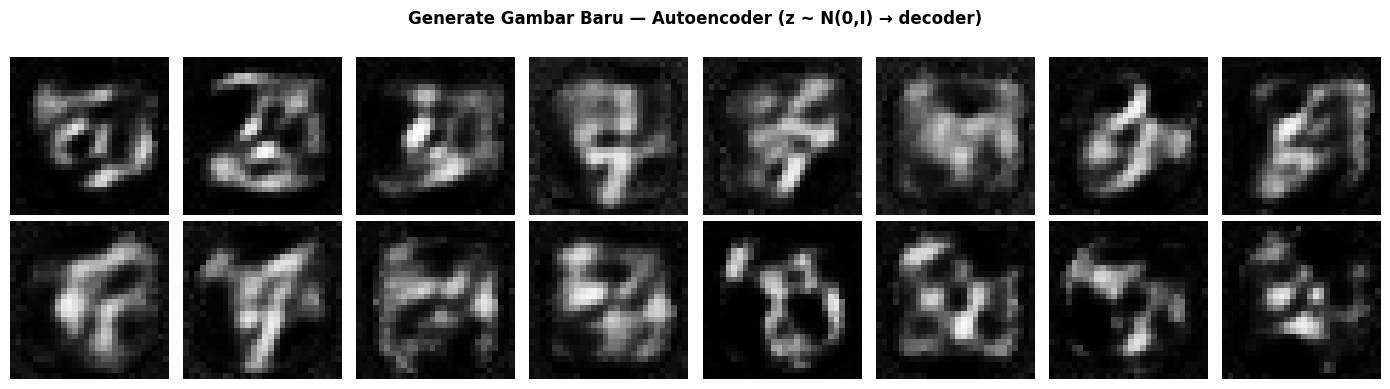

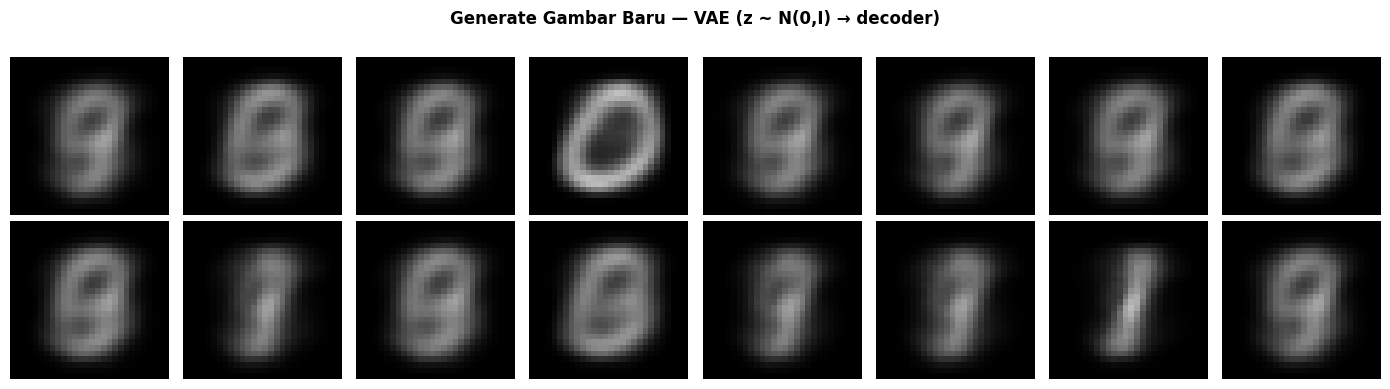

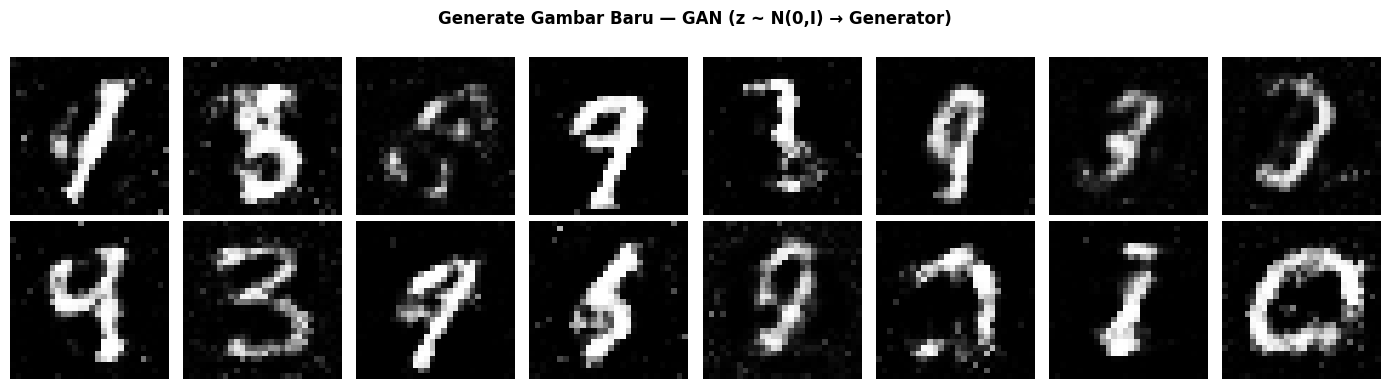

✅ Gambar baru berhasil digenerate dari 3 model!
   Catatan: AE cenderung menghasilkan noise acak karena latent space tidak terstruktur.
   VAE menghasilkan gambar yang lebih bermakna karena z dipaksa mendekati N(0,I).
   GAN menghasilkan gambar paling tajam (jika training konvergen).


In [11]:
# ================================================================
# BAGIAN 8: GENERATE GAMBAR BARU
# Proses sampling:
#   AE/VAE : z ~ N(0,I)  →  decoder(z)  →  gambar baru
#   GAN    : z ~ N(0,I)  →  generator(z) →  gambar baru
# ================================================================

autoencoder.eval(); vae.eval(); generator.eval()

with torch.no_grad():
    # AE: sample random noise di latent space
    z_ae   = torch.randn(16, LATENT_DIM_AE).to(device)
    gen_ae = autoencoder.decoder(z_ae)          # decode

    # VAE: sample dari prior p(z) = N(0, I)
    z_vae   = torch.randn(16, LATENT_DIM_VAE).to(device)
    gen_vae = vae.decoder(z_vae)                # decode

    # GAN: noise z melalui generator
    z_gan   = torch.randn(16, NOISE_DIM).to(device)
    gen_gan = generator(z_gan)                  # G(z)

def show_generated(gen_imgs, title, filename):
    fig, axes = plt.subplots(2, 8, figsize=(14, 4))
    fig.suptitle(title, fontsize=12, fontweight='bold')
    for i in range(16):
        ax  = axes[i//8][i%8]
        img = gen_imgs[i].squeeze().cpu().numpy() * 0.5 + 0.5  # denormalisasi ke [0,1]
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(filename, dpi=100, bbox_inches='tight')
    plt.show()

show_generated(gen_ae,  "Generate Gambar Baru — Autoencoder (z ~ N(0,I) → decoder)",
               '03_ae_generated.png')
show_generated(gen_vae, "Generate Gambar Baru — VAE (z ~ N(0,I) → decoder)",
               '04_vae_generated.png')
show_generated(gen_gan, "Generate Gambar Baru — GAN (z ~ N(0,I) → Generator)",
               '05_gan_generated.png')

print("✅ Gambar baru berhasil digenerate dari 3 model!")
print("   Catatan: AE cenderung menghasilkan noise acak karena latent space tidak terstruktur.")
print("   VAE menghasilkan gambar yang lebih bermakna karena z dipaksa mendekati N(0,I).")
print("   GAN menghasilkan gambar paling tajam (jika training konvergen).")

# ─────────────────────────────────────────
# BAGIAN 9 — VISUALISASI HASIL VISION
# ─────────────────────────────────────────

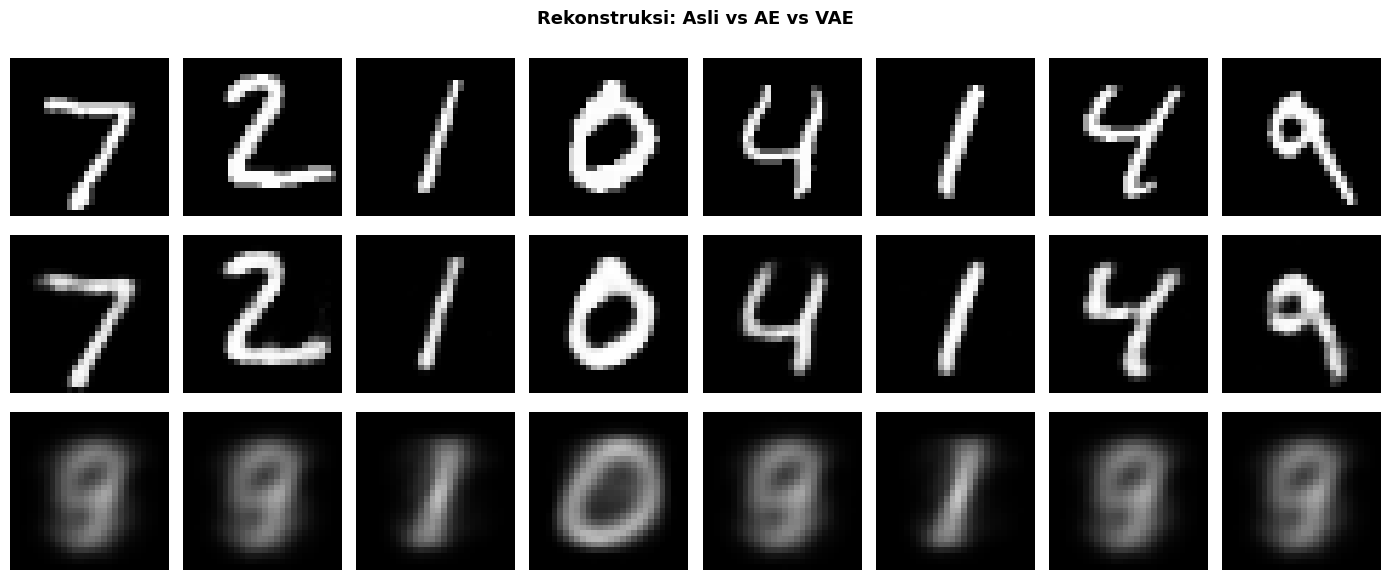

In [12]:
# ================================================================
# BAGIAN 9: VISUALISASI HASIL VISION
# 9A — Rekonstruksi: Asli vs Rekonstruksi (AE dan VAE)
# ================================================================

autoencoder.eval(); vae.eval()
test_imgs, _ = next(iter(test_loader))
test_imgs    = test_imgs[:8].to(device)

with torch.no_grad():
    recon_ae, _       = autoencoder(test_imgs)
    recon_vae, _, _   = vae(test_imgs)

fig, axes = plt.subplots(3, 8, figsize=(14, 6))
fig.suptitle("Rekonstruksi: Asli vs AE vs VAE", fontsize=13, fontweight='bold')
row_titles = ["Asli", "Rekonstruksi AE", "Rekonstruksi VAE"]
imgs_rows  = [test_imgs, recon_ae, recon_vae]

for row, (imgs_r, rtitle) in enumerate(zip(imgs_rows, row_titles)):
    for col in range(8):
        img = imgs_r[col].squeeze().cpu().numpy() * 0.5 + 0.5
        axes[row, col].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(rtitle, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('06_reconstruction_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

Melatih VAE dengan 3 ukuran latent_dim...
✅ Selesai!


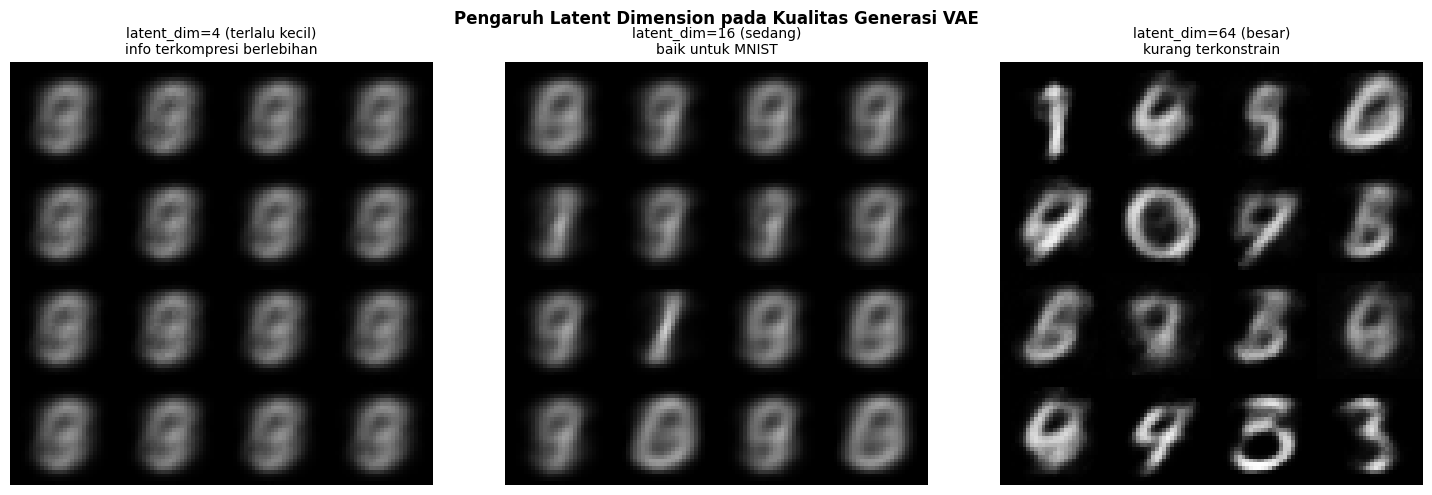

In [13]:
# ================================================================
# BAGIAN 9B — Eksplorasi Latent Space VAE
# Variasi latent_dim: pengaruh ukuran ruang laten
# ================================================================

def quick_vae(latent_dim, epochs=3):
    """Train VAE cepat untuk perbandingan latent_dim."""
    m   = VAE(latent_dim=latent_dim).to(device)
    opt = optim.Adam(m.parameters(), lr=1e-3)
    for _ in range(epochs):
        m.train()
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            xh, mu, lv = m(imgs)
            loss, _, _  = vae_loss_fn(xh, imgs, mu, lv)
            opt.zero_grad(); loss.backward(); opt.step()
    return m

print("Melatih VAE dengan 3 ukuran latent_dim...")
vae_d4  = quick_vae(4)
vae_d64 = quick_vae(64)
print("✅ Selesai!")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Pengaruh Latent Dimension pada Kualitas Generasi VAE",
             fontsize=12, fontweight='bold')

for ax, model, dim, title in zip(
        axes,
        [vae_d4, vae, vae_d64],
        [4, 16, 64],
        ["latent_dim=4 (terlalu kecil)\ninfo terkompresi berlebihan",
         "latent_dim=16 (sedang)\nbaik untuk MNIST",
         "latent_dim=64 (besar)\nkurang terkonstrain"]):
    model.eval()
    with torch.no_grad():
        z   = torch.randn(16, dim).to(device)
        gen = model.decoder(z)
    rows = [np.concatenate([gen[r*4+c].squeeze().cpu().numpy()*0.5+0.5
                             for c in range(4)], axis=1) for r in range(4)]
    grid = np.concatenate(rows, axis=0)
    ax.imshow(grid, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('07_latent_dim_effect.png', dpi=100, bbox_inches='tight')
plt.show()

In [14]:
# ================================================================
# BAGIAN 9C — Analisis Kualitas Gambar Vision
# ================================================================

# Hitung MSE rekonstruksi sebagai ukuran kualitas
autoencoder.eval(); vae.eval()
all_test  = []
mse_ae    = []
mse_vae   = []

with torch.no_grad():
    for imgs, _ in test_loader:
        imgs = imgs.to(device)
        xh_ae, _      = autoencoder(imgs)
        xh_vae, _, _  = vae(imgs)
        mse_ae.append(F.mse_loss(xh_ae, imgs).item())
        mse_vae.append(F.mse_loss(xh_vae, imgs).item())

print("="*45)
print("Analisis Kualitas Rekonstruksi (Test Set)")
print("="*45)
print(f"  AE  MSE rekonstruksi: {np.mean(mse_ae):.5f}")
print(f"  VAE MSE rekonstruksi: {np.mean(mse_vae):.5f}")
print()
print("Catatan Kualitas:")
print("  - AE  : rekonstruksi cukup baik, tapi generate gambar baru sulit")
print("  - VAE : MSE lebih tinggi karena ada regularisasi KL, ")
print("          tapi latent space terstruktur untuk generate gambar baru")
print("  - GAN : tidak bisa diukur dengan MSE; kualitas diukur secara visual")
print("  ⚠ Loss kecil ≠ kualitas generasi bagus!")

Analisis Kualitas Rekonstruksi (Test Set)
  AE  MSE rekonstruksi: 0.03049
  VAE MSE rekonstruksi: 0.24016

Catatan Kualitas:
  - AE  : rekonstruksi cukup baik, tapi generate gambar baru sulit
  - VAE : MSE lebih tinggi karena ada regularisasi KL, 
          tapi latent space terstruktur untuk generate gambar baru
  - GAN : tidak bisa diukur dengan MSE; kualitas diukur secara visual
  ⚠ Loss kecil ≠ kualitas generasi bagus!


---
# BAGIAN TEXT: GENERATIVE AI UNTUK TEKS
---

# ─────────────────────────────────────────
# BAGIAN 10 — LOAD DATASET TEXT
# ─────────────────────────────────────────

In [15]:
# ================================================================
# BAGIAN 10: LOAD DATASET TEXT
# Dataset: Kumpulan kalimat Bahasa Indonesia (buatan sendiri)
# Topik: alam, teknologi, budaya, pendidikan, kehidupan sehari-hari
# ================================================================

corpus = """
aku adalah manusia yang berjalan di bawah langit biru
hujan turun membasahi bumi yang kering dan gersang
angin berhembus membawa aroma bunga yang segar
sungai mengalir menuju samudra yang luas dan dalam
matahari terbit dari timur menerangi hari baru
bintang berkelip di malam yang gelap dan sunyi
bulan bersinar terang menemaniku di malam hari
pohon bergoyang diterpa angin sepoi di sore hari
daun gugur jatuh ke tanah basah setelah hujan
burung bernyanyi menyambut pagi yang cerah
anak kecil berlari di padang rumput yang hijau
nelayan pergi ke laut untuk mencari ikan
petani bekerja keras di sawah yang luas
ibu memasak di dapur dengan penuh kasih sayang
ayah membaca buku di ruang tamu yang nyaman
adik belajar dengan sungguh dan tekun setiap hari
kakak membantu ibu membersihkan rumah bersama
kucing tidur di atas kursi yang empuk dan hangat
anjing berlari kencang di halaman rumah yang luas
ikan berenang di kolam yang jernih dan bersih
teknologi berkembang dengan pesat di zaman modern ini
kecerdasan buatan mengubah cara kita bekerja sehari-hari
komputer membantu manusia menyelesaikan masalah yang sulit
internet menghubungkan seluruh dunia dalam sekejap
data adalah aset penting di era digital yang maju
algoritma belajar dari pengalaman dan data yang ada
model kecerdasan buatan bisa membuat gambar yang indah
bahasa pemrograman digunakan untuk membuat aplikasi canggih
robotika menggabungkan mekanik dan elektronik secara cerdas
sensor mengumpulkan data dari lingkungan sekitar kita
indonesia adalah negara kepulauan yang sangat indah
budaya nusantara sangat kaya dan beragam ragam
bahasa indonesia menyatukan berbagai suku bangsa
pancasila adalah dasar negara indonesia yang kuat
keindahan alam indonesia tiada duanya di seluruh dunia
bali terkenal dengan keindahan budaya dan alamnya
raja ampat memiliki keindahan bawah laut yang memukau
borobudur adalah keajaiban dunia yang sangat megah
komodo hanya bisa ditemukan di indonesia saja
wayang adalah seni budaya asli milik indonesia
pendidikan adalah kunci kemajuan bangsa dan negara
ilmu pengetahuan membuka wawasan dan cakrawala kita
membaca buku menambah pengetahuan dan wawasan kita
belajar tidak pernah ada batasnya sepanjang hayat
guru adalah pahlawan tanpa tanda jasa yang mulia
siswa belajar dengan giat dan penuh semangat juang
universitas menghasilkan generasi penerus bangsa yang cerdas
penelitian memajukan ilmu pengetahuan dan teknologi
inovasi membuat kehidupan manusia lebih mudah dan nyaman
kreativitas adalah kekuatan manusia yang luar biasa
air adalah sumber kehidupan bagi semua makhluk hidup
udara bersih sangat penting untuk kesehatan kita
hutan menyediakan oksigen bagi kehidupan di bumi
laut menyimpan kekayaan alam yang sangat berlimpah
gunung menjulang tinggi menyentuh awan dan langit
pantai menawarkan keindahan yang sangat memukau hati
danau memantulkan cahaya langit biru yang tenang
sawah membentang hijau sejauh mata bisa memandang
kebun buah menghasilkan panen yang sangat melimpah
ladang bunga semerbak harum di pagi hari yang segar
persahabatan adalah harta yang sangat berharga di dunia
cinta kasih menguatkan hubungan antar sesama manusia
keluarga adalah tempat berlindung yang paling nyaman
kebersamaan membuat hidup terasa lebih bermakna dan indah
gotong royong adalah budaya luhur bangsa indonesia
tolong menolong adalah kewajiban kita sebagai sesama manusia
kejujuran adalah pondasi kepercayaan yang paling kuat
keberanian diperlukan untuk meraih impian yang besar
kesabaran adalah kunci kesuksesan dalam jangka panjang
kerja keras tidak pernah mengkhianati hasil akhirnya
mimpi besar selalu dimulai dari langkah kecil pertama
setiap hari adalah kesempatan baru untuk terus berkembang
masa depan dibentuk oleh setiap pilihan kita hari ini
sukses adalah perjalanan panjang bukan hanya tujuan akhir
kegagalan adalah pelajaran berharga untuk bangkit kembali
semangat pantang menyerah akan membawa kita ke puncak
generasi muda adalah harapan dan masa depan bangsa
dengan tekad yang kuat semua impian bisa diraih
jadilah cahaya di tengah kegelapan dan kesulitan
hidup menjadi bermakna ketika kita memberi manfaat
kebaikan sekecil apapun membawa dampak yang sangat besar
senyum adalah bahasa universal yang paling indah
musik mampu mengungkapkan perasaan yang tidak bisa diucapkan
seni adalah ekspresi jiwa yang paling bebas dan murni
tari tradisional menceritakan sejarah dan budaya bangsa
lukisan mengabadikan keindahan dunia untuk selamanya
puisi adalah bahasa hati yang paling dalam dan tulus
novel membawa kita ke dunia yang sama sekali berbeda
film menghadirkan kisah kehidupan nyata di layar lebar
fotografi menangkap momen berharga yang tidak bisa terulang
arsitektur menggabungkan fungsi dan keindahan secara harmonis
kuliner nusantara sangat kaya rasa dan bumbu rempah
rendang adalah masakan indonesia yang terkenal di dunia
gado gado menyajikan perpaduan rasa yang sangat nikmat
sate ayam dipanggang dengan bumbu kacang yang lezat
nasi goreng adalah makanan favorit banyak orang indonesia
bakso kuah panas sangat menghangatkan perut di malam hari
kopi pagi hari selalu mengawali hari dengan penuh semangat
teh herbal yang hangat dapat menenangkan jiwa dan pikiran
buah tropis indonesia kaya akan vitamin dan cita rasa
""".strip()

lines = [l.strip() for l in corpus.split('\n') if l.strip()]
full_text = ' '.join(lines)

print("✅ Dataset teks berhasil dimuat!")
print(f"   Jumlah kalimat  : {len(lines)}")
print(f"   Total karakter  : {len(full_text):,}")
print(f"   Total kata      : {len(full_text.split()):,}")
print(f"\nContoh 3 kalimat pertama:")
for l in lines[:3]:
    print(f"   '{l}'")

✅ Dataset teks berhasil dimuat!
   Jumlah kalimat  : 100
   Total karakter  : 5,224
   Total kata      : 756

Contoh 3 kalimat pertama:
   'aku adalah manusia yang berjalan di bawah langit biru'
   'hujan turun membasahi bumi yang kering dan gersang'
   'angin berhembus membawa aroma bunga yang segar'


# ─────────────────────────────────────────
# BAGIAN 11 — PREPROCESSING TEXT
# ─────────────────────────────────────────

In [16]:
# ================================================================
# BAGIAN 11: PREPROCESSING TEXT
# Langkah:
#   1. Buat vocabulary (semua karakter unik)
#   2. Buat mapping char ↔ index
#   3. Encode teks ke urutan indeks
#   4. Buat sliding window dataset (input, target)
# ================================================================

# --- 11.1 Vocabulary ---
chars     = sorted(list(set(full_text)))
vocab_size = len(chars)
char2idx  = {ch: i for i, ch in enumerate(chars)}
idx2char  = {i: ch for ch, i in char2idx.items()}

print(f"Vocabulary size   : {vocab_size} karakter unik")
print(f"Isi vocabulary    : {repr(''.join(chars[:40]))}...")

# --- 11.2 Encode teks ke indeks ---
encoded = [char2idx[ch] for ch in full_text]
print(f"\nTotal token (karakter): {len(encoded):,}")
print(f"Contoh teks    : '{full_text[:30]}'")
print(f"Contoh encoded : {encoded[:15]}")
print(f"Decode balik   : '{''.join(idx2char[i] for i in encoded[:30])}'")

# --- 11.3 Buat Dataset (sliding window) ---
SEQ_LEN = 50   # panjang konteks input

class TextDataset(Dataset):
    """Dataset sliding window untuk character-level text generation.
    Input : x_1, x_2, ..., x_t      (SEQ_LEN token)
    Target: x_2, x_3, ..., x_{t+1}  (token berikutnya untuk setiap posisi)
    """
    def __init__(self, data, seq_len):
        self.data    = data
        self.seq_len = seq_len
    def __len__(self):
        return len(self.data) - self.seq_len
    def __getitem__(self, idx):
        x = torch.tensor(self.data[idx:idx+self.seq_len],   dtype=torch.long)
        y = torch.tensor(self.data[idx+1:idx+self.seq_len+1], dtype=torch.long)
        return x, y

text_dataset = TextDataset(encoded, SEQ_LEN)
text_loader  = DataLoader(text_dataset, batch_size=64, shuffle=True)

print(f"\nDataset text    : {len(text_dataset):,} samples")
print(f"Jumlah batch    : {len(text_loader)}")

xb, yb = next(iter(text_loader))
print(f"Shape input     : {xb.shape}  (Batch × SeqLen)")
print(f"Shape target    : {yb.shape}  (Batch × SeqLen)")

# Tampilkan contoh pasangan input–target
sample_x = ''.join(idx2char[i] for i in xb[0].tolist())
sample_y = ''.join(idx2char[i] for i in yb[0].tolist())
print(f"\nContoh input  : '{sample_x[:40]}...'")
print(f"Contoh target : '{sample_y[:40]}...'")
print("(target = input digeser 1 posisi ke kanan)")

Vocabulary size   : 26 karakter unik
Isi vocabulary    : ' -abcdefghijklmnoprstuvwyz'...

Total token (karakter): 5,224
Contoh teks    : 'aku adalah manusia yang berjal'
Contoh encoded : [2, 12, 21, 0, 2, 5, 2, 13, 2, 9, 0, 14, 2, 15, 21]
Decode balik   : 'aku adalah manusia yang berjal'

Dataset text    : 5,174 samples
Jumlah batch    : 81
Shape input     : torch.Size([64, 50])  (Batch × SeqLen)
Shape target    : torch.Size([64, 50])  (Batch × SeqLen)

Contoh input  : 'pikiran buah tropis indonesia kaya akan ...'
Contoh target : 'ikiran buah tropis indonesia kaya akan v...'
(target = input digeser 1 posisi ke kanan)


# ─────────────────────────────────────────
# BAGIAN 12 — DEFINISI MODEL GENERATIF TEXT
# ─────────────────────────────────────────

In [17]:
# ================================================================
# BAGIAN 12: DEFINISI MODEL GENERATIF TEXT
# Model yang diimplementasikan:
#   D. LSTM Text Generator
#   E. Mini GPT (Transformer Decoder)
# ================================================================

# ---------------------------------------------------------------
# MODEL D: LSTM TEXT GENERATOR
# Alur: token → Embedding → LSTM → FC → distribusi token berikutnya
# ---------------------------------------------------------------
class LSTMTextGenerator(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout=0.3):
        super().__init__()
        # Embedding: setiap karakter → vektor dense
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        # LSTM: h_t = LSTM(x_t, h_{t-1})
        # h_t menangkap konteks semua token sebelumnya
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        # Output: distribusi probabilitas atas vocab
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        emb    = self.dropout(self.embedding(x))  # (B, T, embed_dim)
        out, h = self.lstm(emb, hidden)           # (B, T, hidden_dim)
        logits = self.fc(self.dropout(out))        # (B, T, vocab_size)
        return logits, h

# ---------------------------------------------------------------
# MODEL E: MINI GPT (TRANSFORMER DECODER)
# Alur: token → Embedding + Pos.Emb → [Transformer Block × N] → FC
# ---------------------------------------------------------------
class TransformerBlock(nn.Module):
    """Satu blok Transformer:
    1. Causal Self-Attention: Attention(Q,K,V) = softmax(QKᵀ/√d_k)·V
    2. Feed Forward Network
    Keduanya dengan Residual Connection + LayerNorm
    """
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        # Multi-head self-attention
        self.attn  = nn.MultiheadAttention(embed_dim, num_heads,
                                            dropout=dropout, batch_first=True)
        # Feed Forward
        self.ff    = nn.Sequential(
            nn.Linear(embed_dim, ff_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim)
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # 1. Causal Self-Attention + Add & Norm
        a, _ = self.attn(x, x, x, attn_mask=mask)   # Q=K=V=x
        x    = self.norm1(x + self.drop(a))
        # 2. Feed Forward + Add & Norm
        x    = self.norm2(x + self.drop(self.ff(x)))
        return x

class MiniGPT(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers,
                 ff_dim, max_seq_len, dropout=0.1):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, embed_dim)
        self.pos_emb = nn.Embedding(max_seq_len, embed_dim)
        self.blocks  = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        self.norm    = nn.LayerNorm(embed_dim)
        self.head    = nn.Linear(embed_dim, vocab_size)
        self.drop    = nn.Dropout(dropout)
        self.max_seq = max_seq_len

    def forward(self, x):
        B, T   = x.shape
        # Causal mask: token ke-t hanya boleh 'melihat' token 1..t
        mask   = torch.triu(torch.ones(T, T), diagonal=1).bool().to(device)
        pos    = torch.arange(T, device=device).unsqueeze(0)
        h      = self.drop(self.tok_emb(x) + self.pos_emb(pos))
        for blk in self.blocks:
            h  = blk(h, mask)
        logits = self.head(self.norm(h))   # (B, T, vocab_size)
        return logits

# Inisialisasi model teks
EMBED_DIM   = 64
HIDDEN_DIM  = 256
NUM_LAYERS  = 2
T_NUM_HEADS = 4
T_FF_DIM    = 256

lstm_model  = LSTMTextGenerator(
    vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS).to(device)
gpt_model   = MiniGPT(
    vocab_size, EMBED_DIM, T_NUM_HEADS, NUM_LAYERS,
    T_FF_DIM, SEQ_LEN).to(device)

print("✅ Model teks berhasil dibuat!")
print("\nLSTM Text Generator:"); count_parameters(lstm_model)
print("Mini GPT (Transformer):"); count_parameters(gpt_model)

✅ Model teks berhasil dibuat!

LSTM Text Generator:
  Jumlah parameter trainable: 864,410
Mini GPT (Transformer):
  Jumlah parameter trainable: 106,650


106650

# ─────────────────────────────────────────
# BAGIAN 13 — PENJELASAN RUMUS MODEL TEXT
# ─────────────────────────────────────────

## BAGIAN 13: Penjelasan Rumus Model Text

---
### 🟡 D. LSTM Text Generator

**Prinsip text generation (chain rule):**
$$p(x_1, x_2, \ldots, x_T) = \prod_{t=1}^{T} p(x_t \mid x_1, \ldots, x_{t-1})$$

| Rumus | Arti | Kode PyTorch |
|---|---|---|
| `h_t = LSTM(x_t, h_{t-1})` | Hidden state meringkas konteks sebelumnya | `self.lstm(emb, hidden)` |
| `ŷ_t = softmax(W·h_t)` | Distribusi probabilitas token berikutnya | `F.softmax(logits, dim=-1)` |
| `L = −Σ y·log(ŷ)` | Cross entropy loss | `nn.CrossEntropyLoss()` |
| `x_{t+1} ~ ŷ_t` | Sampling token berikutnya | `torch.multinomial(probs, 1)` |

**Penjelasan:** LSTM mempertahankan hidden state h_t yang meringkas semua token sebelumnya. Output layer mengubah h_t menjadi distribusi probabilitas atas seluruh vocabulary. Sampling dilakukan berdasarkan distribusi tersebut.

---
### 🟢 E. Mini GPT (Transformer)

**Self-Attention:**
$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

| Rumus | Arti | Kode PyTorch |
|---|---|---|
| `Q, K, V = xW_Q, xW_K, xW_V` | Proyeksi query, key, value | Dalam `nn.MultiheadAttention` |
| `score = QKᵀ / √d_k` | Skor perhatian antar token | Dalam `nn.MultiheadAttention` |
| `mask = triu(ones, 1)` | Causal mask: larang lihat masa depan | `torch.triu(..., diagonal=1)` |
| `softmax(score)·V` | Weighted sum of values | `nn.MultiheadAttention()` |
| `L = −Σ y·log(ŷ)` | Cross entropy loss sama seperti LSTM | `nn.CrossEntropyLoss()` |

**Penjelasan:** Transformer menghitung perhatian antar semua pasangan token dalam sekali operasi (paralel), berbeda dengan LSTM yang sekuensial. Causal mask memastikan token hanya bisa melihat token sebelumnya, bukan yang akan datang.

In [18]:
# ================================================================
# BAGIAN 13 (lanjutan): Tabel Hubungan Rumus ↔ Kode (Text)
# ================================================================

print("="*80)
print("TABEL HUBUNGAN RUMUS ↔ KODE PYTORCH (Text)")
print("="*80)
rows_text = [
    ("Embedding",        "char → dense vector",           "nn.Embedding(vocab, embed)"),
    ("LSTM step",        "h_t = LSTM(x_t, h_{t-1})",     "nn.LSTM(..., batch_first=True)"),
    ("Output proj",      "ŷ = softmax(W·h_t)",            "nn.Linear(hidden, vocab)"),
    ("Cross Entropy",    "L = −Σ y·log(ŷ)",              "nn.CrossEntropyLoss()"),
    ("Sampling",         "x_{t+1} ~ ŷ / T",              "torch.multinomial(probs, 1)"),
    ("Pos Embedding",    "pos ∈ R^embed",                 "nn.Embedding(max_seq, embed)"),
    ("Self-Attention",   "softmax(QKᵀ/√d_k)·V",          "nn.MultiheadAttention()"),
    ("Causal Mask",      "mask = triu(1, diag=1)",        "torch.triu(ones, diagonal=1)"),
    ("Add & Norm",       "x = LN(x + Attn(x))",          "nn.LayerNorm(embed_dim)"),
    ("Feed Forward",     "FFN(x) = GELU(xW₁+b₁)W₂+b₂",  "nn.Linear + nn.GELU"),
    ("Temperature",      "logit / T (atur randomness)",   "last_logit / temperature"),
]
print(f"{'Konsep':<18} {'Rumus':<35} {'Kode PyTorch'}")
print("-"*80)
for r in rows_text:
    print(f"{r[0]:<18} {r[1]:<35} {r[2]}")

TABEL HUBUNGAN RUMUS ↔ KODE PYTORCH (Text)
Konsep             Rumus                               Kode PyTorch
--------------------------------------------------------------------------------
Embedding          char → dense vector                 nn.Embedding(vocab, embed)
LSTM step          h_t = LSTM(x_t, h_{t-1})            nn.LSTM(..., batch_first=True)
Output proj        ŷ = softmax(W·h_t)                  nn.Linear(hidden, vocab)
Cross Entropy      L = −Σ y·log(ŷ)                     nn.CrossEntropyLoss()
Sampling           x_{t+1} ~ ŷ / T                     torch.multinomial(probs, 1)
Pos Embedding      pos ∈ R^embed                       nn.Embedding(max_seq, embed)
Self-Attention     softmax(QKᵀ/√d_k)·V                 nn.MultiheadAttention()
Causal Mask        mask = triu(1, diag=1)              torch.triu(ones, diagonal=1)
Add & Norm         x = LN(x + Attn(x))                 nn.LayerNorm(embed_dim)
Feed Forward       FFN(x) = GELU(xW₁+b₁)W₂+b₂          nn.Linear + nn.GELU

# ─────────────────────────────────────────
# BAGIAN 14 — TRAINING MODEL TEXT
# ─────────────────────────────────────────

In [19]:
# ================================================================
# BAGIAN 14: TRAINING MODEL TEXT
# 14A — Training LSTM
# ================================================================

optimizer_lstm = optim.Adam(lstm_model.parameters(), lr=1e-3)
scheduler_lstm = optim.lr_scheduler.StepLR(optimizer_lstm, step_size=5, gamma=0.5)
criterion_text = nn.CrossEntropyLoss()   # L = −Σ y·log(ŷ)

LSTM_EPOCHS = 15
lstm_losses  = []

print("Training LSTM Text Generator...")
start = time.time()

for epoch in range(LSTM_EPOCHS):
    lstm_model.train()
    ep_loss = 0
    for xb, yb in text_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits, _ = lstm_model(xb)
        # Reshape: (Batch, SeqLen, Vocab) → (Batch*SeqLen, Vocab)
        loss = criterion_text(logits.reshape(-1, vocab_size), yb.reshape(-1))
        optimizer_lstm.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)  # clip gradient
        optimizer_lstm.step()
        ep_loss += loss.item()
    scheduler_lstm.step()
    avg = ep_loss / len(text_loader)
    lstm_losses.append(avg)
    print(f"  Epoch [{epoch+1:2d}/{LSTM_EPOCHS}] | Loss: {avg:.4f} | Perplexity: {np.exp(avg):.2f}")

timer(start, "LSTM")

Training LSTM Text Generator...
  Epoch [ 1/15] | Loss: 2.3881 | Perplexity: 10.89
  Epoch [ 2/15] | Loss: 1.7585 | Perplexity: 5.80
  Epoch [ 3/15] | Loss: 1.4175 | Perplexity: 4.13
  Epoch [ 4/15] | Loss: 1.0912 | Perplexity: 2.98
  Epoch [ 5/15] | Loss: 0.7989 | Perplexity: 2.22
  Epoch [ 6/15] | Loss: 0.6067 | Perplexity: 1.83
  Epoch [ 7/15] | Loss: 0.5147 | Perplexity: 1.67
  Epoch [ 8/15] | Loss: 0.4456 | Perplexity: 1.56
  Epoch [ 9/15] | Loss: 0.3951 | Perplexity: 1.48
  Epoch [10/15] | Loss: 0.3586 | Perplexity: 1.43
  Epoch [11/15] | Loss: 0.3313 | Perplexity: 1.39
  Epoch [12/15] | Loss: 0.3188 | Perplexity: 1.38
  Epoch [13/15] | Loss: 0.3059 | Perplexity: 1.36
  Epoch [14/15] | Loss: 0.2960 | Perplexity: 1.34
  Epoch [15/15] | Loss: 0.2871 | Perplexity: 1.33
  ⏱ Waktu training LSTM: 162.3 detik (2.7 menit)


In [20]:
# ================================================================
# BAGIAN 14B — Training Mini GPT (Transformer)
# ================================================================

optimizer_gpt = optim.AdamW(gpt_model.parameters(), lr=1e-3, weight_decay=0.01)
scheduler_gpt = optim.lr_scheduler.CosineAnnealingLR(optimizer_gpt, T_max=LSTM_EPOCHS)

GPT_EPOCHS = 15
gpt_losses  = []

print("Training Mini GPT (Transformer)...")
start = time.time()

for epoch in range(GPT_EPOCHS):
    gpt_model.train()
    ep_loss = 0
    for xb, yb in text_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits  = gpt_model(xb)
        loss    = criterion_text(logits.reshape(-1, vocab_size), yb.reshape(-1))
        optimizer_gpt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gpt_model.parameters(), 1.0)
        optimizer_gpt.step()
        ep_loss += loss.item()
    scheduler_gpt.step()
    avg = ep_loss / len(text_loader)
    gpt_losses.append(avg)
    print(f"  Epoch [{epoch+1:2d}/{GPT_EPOCHS}] | Loss: {avg:.4f} | Perplexity: {np.exp(avg):.2f}")

timer(start, "Mini GPT")

Training Mini GPT (Transformer)...
  Epoch [ 1/15] | Loss: 2.3625 | Perplexity: 10.62
  Epoch [ 2/15] | Loss: 2.0998 | Perplexity: 8.16
  Epoch [ 3/15] | Loss: 2.0423 | Perplexity: 7.71
  Epoch [ 4/15] | Loss: 1.9930 | Perplexity: 7.34
  Epoch [ 5/15] | Loss: 1.9392 | Perplexity: 6.95
  Epoch [ 6/15] | Loss: 1.8856 | Perplexity: 6.59
  Epoch [ 7/15] | Loss: 1.8284 | Perplexity: 6.22
  Epoch [ 8/15] | Loss: 1.7826 | Perplexity: 5.95
  Epoch [ 9/15] | Loss: 1.7441 | Perplexity: 5.72
  Epoch [10/15] | Loss: 1.7110 | Perplexity: 5.53
  Epoch [11/15] | Loss: 1.6854 | Perplexity: 5.39
  Epoch [12/15] | Loss: 1.6674 | Perplexity: 5.30
  Epoch [13/15] | Loss: 1.6582 | Perplexity: 5.25
  Epoch [14/15] | Loss: 1.6514 | Perplexity: 5.21
  Epoch [15/15] | Loss: 1.6465 | Perplexity: 5.19
  ⏱ Waktu training Mini GPT: 149.8 detik (2.5 menit)


# ─────────────────────────────────────────
# BAGIAN 15 — GENERATE TEXT DARI PROMPT
# ─────────────────────────────────────────

In [21]:
# ================================================================
# BAGIAN 15: GENERATE TEXT DARI PROMPT
# Proses:
#   prompt → tokenize → model → logit / temperature → softmax
#   → multinomial sampling → token baru → ulangi
# ================================================================

def generate_lstm(model, prompt, length=150, temperature=0.8):
    """Generate teks menggunakan LSTM.
    temperature > 1  → lebih random/beragam
    temperature < 1  → lebih deterministik/fokus
    """
    model.eval()
    ids       = [char2idx[c] for c in prompt if c in char2idx]
    generated = list(prompt)
    with torch.no_grad():
        x      = torch.tensor([ids], dtype=torch.long).to(device)
        logits, hidden = model(x)
        for _ in range(length):
            last   = logits[0, -1, :] / temperature
            probs  = F.softmax(last, dim=0)
            nxt    = torch.multinomial(probs, 1).item()   # sampling
            generated.append(idx2char[nxt])
            x      = torch.tensor([[nxt]], dtype=torch.long).to(device)
            logits, hidden = model(x, hidden)
    return ''.join(generated)

def generate_gpt(model, prompt, length=150, temperature=0.8, top_k=10):
    """Generate teks menggunakan Mini GPT dengan top-k sampling."""
    model.eval()
    ids       = [char2idx[c] for c in prompt if c in char2idx]
    generated = list(prompt)
    with torch.no_grad():
        for _ in range(length):
            ctx    = ids[-SEQ_LEN:]
            x      = torch.tensor([ctx], dtype=torch.long).to(device)
            logits = model(x)[0, -1, :] / temperature
            # Top-k: zero out semua logit selain top-k terbesar
            topk, _ = torch.topk(logits, top_k)
            logits  = logits.masked_fill(logits < topk[-1], float('-inf'))
            probs   = F.softmax(logits, dim=0)
            nxt     = torch.multinomial(probs, 1).item()
            generated.append(idx2char[nxt])
            ids.append(nxt)
    return ''.join(generated)

# Daftar prompt untuk pengujian
test_prompts = [
    "aku adalah",
    "teknologi berkembang",
    "indonesia adalah",
    "pendidikan adalah",
]

print("="*65)
print("HASIL TEXT GENERATION — LSTM vs Mini GPT")
print("="*65)

for prompt in test_prompts:
    out_lstm = generate_lstm(lstm_model, prompt, length=100, temperature=0.8)
    out_gpt  = generate_gpt(gpt_model,   prompt, length=100, temperature=0.8)
    print(f"\n📝 Prompt: '{prompt}'")
    print(f"   LSTM : {out_lstm}")
    print(f"   GPT  : {out_gpt}")

print("\n" + "="*65)

HASIL TEXT GENERATION — LSTM vs Mini GPT

📝 Prompt: 'aku adalah'
   LSTM : aku adalah masakan indonesia yang terkenal di dunia gado gado menyajikan perpaduan rasa yang sangat nikmat sat
   GPT  : aku adalah dan sangat kependan hanyan dita kepanyan dan selarah megabaya angat parat sangasia yang berlajan ke

📝 Prompt: 'teknologi berkembang'
   LSTM : teknologi berkembang dengan pesat di zaman modern ini kecerdasan buatan mengubah cara kita bekerja sehari-dari selalu me
   GPT  : teknologi berkembangkan bangsa bar dongata bersa ki menyangka ti adalah saya luketan kuncalir amakani makituk membukan b

📝 Prompt: 'indonesia adalah'
   LSTM : indonesia adalah negara kepulauan yang sangat indah budaya nusantara sangat kaya rasa dan bumbu rempah rendang adala
   GPT  : indonesia adalah setir keharita hidup an basa yang telimu berlikan ayang besanga pangang di sengalan datrunivemang d

📝 Prompt: 'pendidikan adalah'
   LSTM : pendidikan adalah kunci kemajuan bangsa dan negara ilmu pengetahuan memb

In [22]:
# ================================================================
# BAGIAN 15 (lanjutan): Eksperimen Pengaruh Panjang Prompt
# ================================================================

base_prompt = "teknologi berkembang dengan pesat di zaman"
lengths     = [5, 15, 30, len(base_prompt)]

print("="*70)
print("EKSPERIMEN: PENGARUH PANJANG PROMPT TERHADAP OUTPUT")
print("="*70)

for plen in lengths:
    p           = base_prompt[:plen]
    out_lstm    = generate_lstm(lstm_model, p, length=70)
    out_gpt     = generate_gpt(gpt_model,   p, length=70)
    print(f"\n🔹 Prompt [{plen:2d} karakter]: '{p}'")
    print(f"   LSTM : {out_lstm}")
    print(f"   GPT  : {out_gpt}")

print("\n" + "="*70)
print("\nEKSPERIMEN: PENGARUH TEMPERATURE")
print("="*70)
prompt_temp = "indonesia adalah negara"
for temp in [0.3, 0.8, 1.5]:
    out = generate_lstm(lstm_model, prompt_temp, length=80, temperature=temp)
    print(f"\n  Temperature={temp}: {out}")

EKSPERIMEN: PENGARUH PANJANG PROMPT TERHADAP OUTPUT

🔹 Prompt [ 5 karakter]: 'tekno'
   LSTM : teknologi berkembang dengan pesat di zaman modern ini kecerdasan buatan men
   GPT  : teknovenisik mencurngkah sengatan mengembangkan hari yang biru saga hari ya

🔹 Prompt [15 karakter]: 'teknologi berke'
   LSTM : teknologi berkembang dengan pesat di zaman modern ini kecerdasan buatan mengubah cara
   GPT  : teknologi berkenincasi memang punguanuh dan yang luncerkas penyaling bunga terjarg ma

🔹 Prompt [30 karakter]: 'teknologi berkembang dengan pe'
   LSTM : teknologi berkembang dengan pesat di zaman modern ini kecerdasan buatan mengubah cara kita bekerja s
   GPT  : teknologi berkembang dengan pengengan adan kegan kenolersan bara da di adalah dengalah yang yang tek

🔹 Prompt [42 karakter]: 'teknologi berkembang dengan pesat di zaman'
   LSTM : teknologi berkembang dengan pesat di zaman modern ini kecerdasan buatan mengubah cara kita bekerja sehari-hari k
   GPT  : teknologi berkembang deng

# ─────────────────────────────────────────
# BAGIAN 16 — VISUALISASI LOSS
# ─────────────────────────────────────────

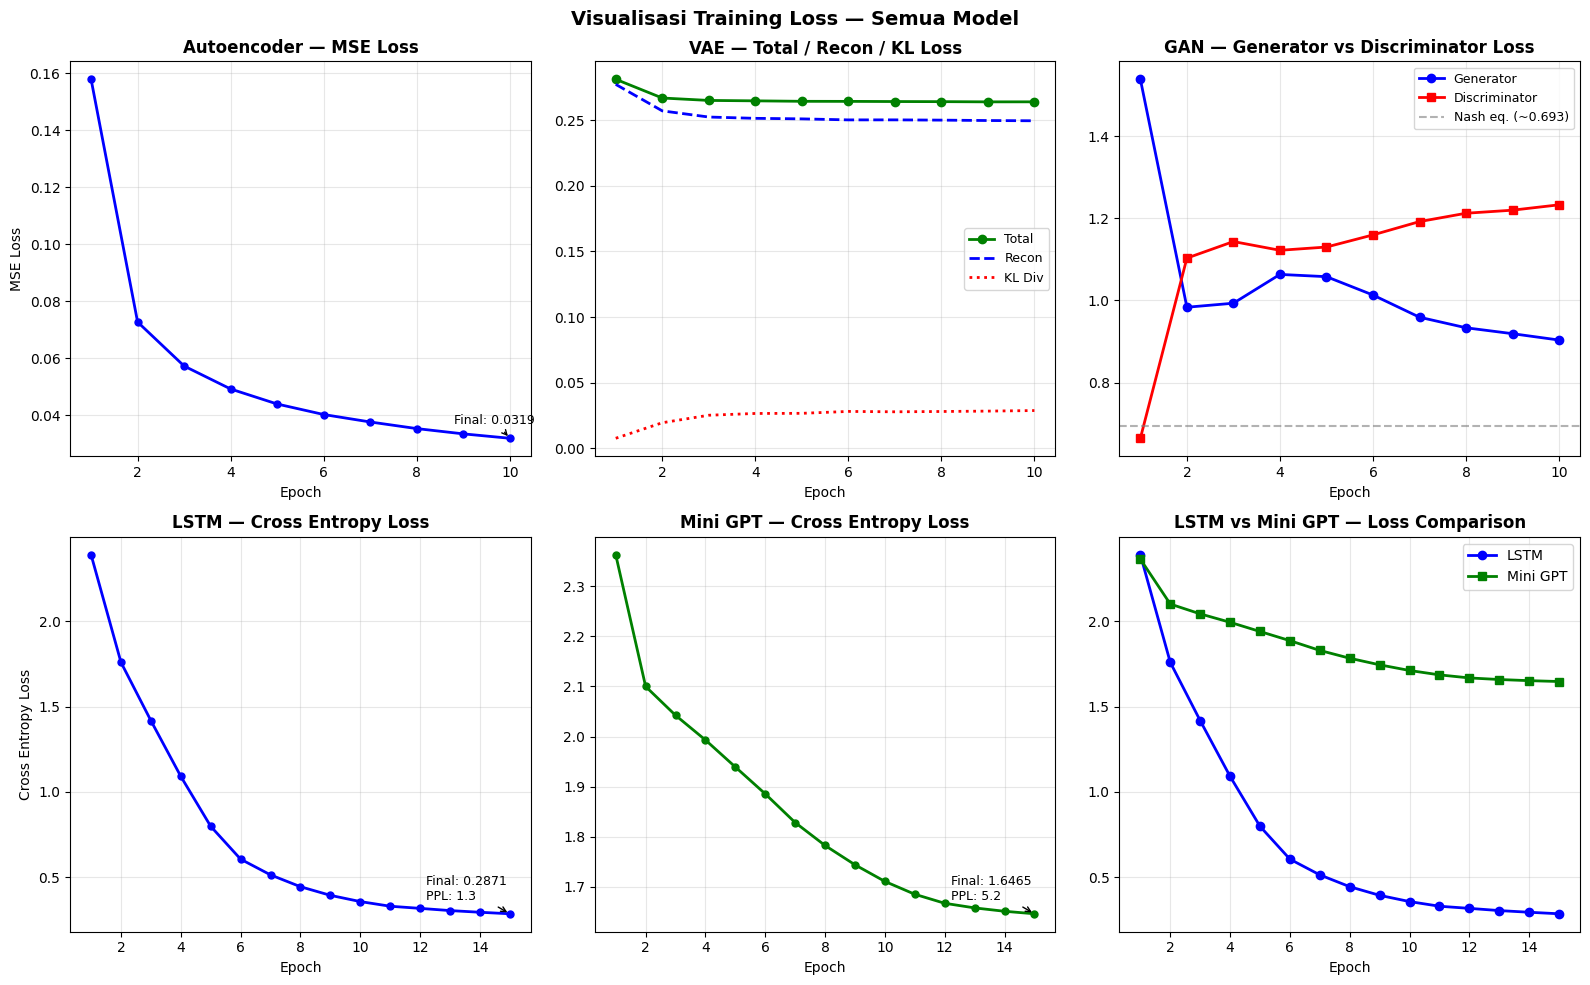


RINGKASAN LOSS AKHIR
  AE  MSE loss       : 0.03191
  VAE total loss     : 0.26393
  GAN G/D loss       : 0.9035 / 1.2330
  LSTM CE loss       : 0.2871  (PPL = 1.33)
  Mini GPT CE loss   : 1.6465  (PPL = 5.19)


In [23]:
# ================================================================
# BAGIAN 16: VISUALISASI LOSS — SEMUA MODEL
# ================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Visualisasi Training Loss — Semua Model", fontsize=14, fontweight='bold')

# --- Vision: AE ---
ax = axes[0, 0]
ax.plot(range(1, AE_EPOCHS+1), ae_losses, 'b-o', linewidth=2, markersize=5)
ax.set_title("Autoencoder — MSE Loss", fontweight='bold')
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.grid(True, alpha=0.3)
ax.annotate(f"Final: {ae_losses[-1]:.4f}", xy=(AE_EPOCHS, ae_losses[-1]),
            xytext=(-40, 10), textcoords='offset points', fontsize=9,
            arrowprops=dict(arrowstyle='->'))

# --- Vision: VAE ---
ax = axes[0, 1]
ax.plot(range(1, VAE_EPOCHS+1), vae_losses,  'g-o', label='Total',  linewidth=2)
ax.plot(range(1, VAE_EPOCHS+1), vae_recon_l, 'b--', label='Recon',  linewidth=2)
ax.plot(range(1, VAE_EPOCHS+1), vae_kl_l,    'r:',  label='KL Div', linewidth=2)
ax.set_title("VAE — Total / Recon / KL Loss", fontweight='bold')
ax.set_xlabel("Epoch"); ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Vision: GAN ---
ax = axes[0, 2]
ax.plot(range(1, GAN_EPOCHS+1), gan_g_losses, 'b-o', label='Generator',     linewidth=2)
ax.plot(range(1, GAN_EPOCHS+1), gan_d_losses, 'r-s', label='Discriminator', linewidth=2)
ax.axhline(y=np.log(2), color='gray', linestyle='--', alpha=0.6, label='Nash eq. (~0.693)')
ax.set_title("GAN — Generator vs Discriminator Loss", fontweight='bold')
ax.set_xlabel("Epoch"); ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Text: LSTM ---
ax = axes[1, 0]
ax.plot(range(1, LSTM_EPOCHS+1), lstm_losses, 'b-o', linewidth=2, markersize=5)
ax.set_title("LSTM — Cross Entropy Loss", fontweight='bold')
ax.set_xlabel("Epoch"); ax.set_ylabel("Cross Entropy Loss")
ax.grid(True, alpha=0.3)
ax.annotate(f"Final: {lstm_losses[-1]:.4f}\nPPL: {np.exp(lstm_losses[-1]):.1f}",
            xy=(LSTM_EPOCHS, lstm_losses[-1]),
            xytext=(-60, 10), textcoords='offset points', fontsize=9,
            arrowprops=dict(arrowstyle='->'))

# --- Text: Mini GPT ---
ax = axes[1, 1]
ax.plot(range(1, GPT_EPOCHS+1), gpt_losses, 'g-o', linewidth=2, markersize=5)
ax.set_title("Mini GPT — Cross Entropy Loss", fontweight='bold')
ax.set_xlabel("Epoch")
ax.grid(True, alpha=0.3)
ax.annotate(f"Final: {gpt_losses[-1]:.4f}\nPPL: {np.exp(gpt_losses[-1]):.1f}",
            xy=(GPT_EPOCHS, gpt_losses[-1]),
            xytext=(-60, 10), textcoords='offset points', fontsize=9,
            arrowprops=dict(arrowstyle='->'))

# --- Text: LSTM vs GPT ---
ax = axes[1, 2]
ax.plot(range(1, LSTM_EPOCHS+1), lstm_losses, 'b-o', label='LSTM',      linewidth=2)
ax.plot(range(1, GPT_EPOCHS+1),  gpt_losses,  'g-s', label='Mini GPT',  linewidth=2)
ax.set_title("LSTM vs Mini GPT — Loss Comparison", fontweight='bold')
ax.set_xlabel("Epoch"); ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('08_all_losses.png', dpi=100, bbox_inches='tight')
plt.show()

# Perplexity summary
print("\n" + "="*45)
print("RINGKASAN LOSS AKHIR")
print("="*45)
print(f"  AE  MSE loss       : {ae_losses[-1]:.5f}")
print(f"  VAE total loss     : {vae_losses[-1]:.5f}")
print(f"  GAN G/D loss       : {gan_g_losses[-1]:.4f} / {gan_d_losses[-1]:.4f}")
print(f"  LSTM CE loss       : {lstm_losses[-1]:.4f}  (PPL = {np.exp(lstm_losses[-1]):.2f})")
print(f"  Mini GPT CE loss   : {gpt_losses[-1]:.4f}  (PPL = {np.exp(gpt_losses[-1]):.2f})")

# ─────────────────────────────────────────
# BAGIAN 17 — PERBANDINGAN HASIL
# ─────────────────────────────────────────

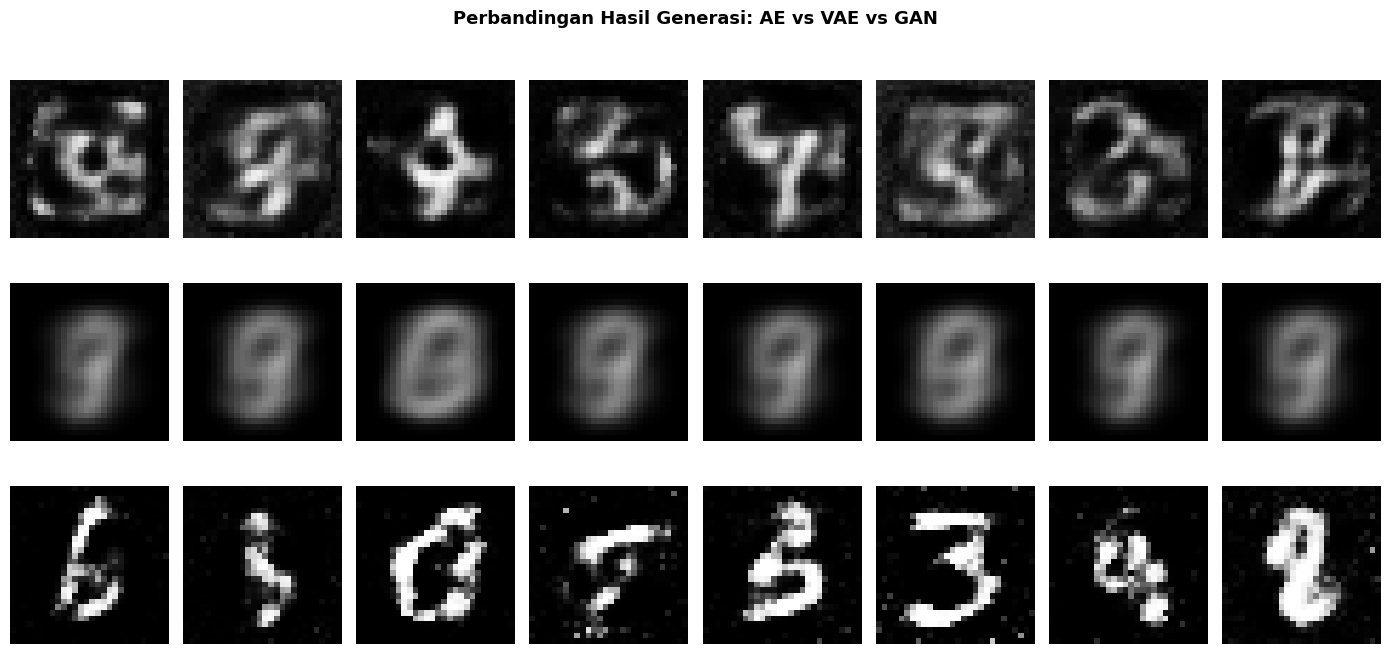

In [24]:
# ================================================================
# BAGIAN 17: PERBANDINGAN HASIL
# 17A — Perbandingan Visual: AE vs VAE vs GAN (gambar digenerate)
# ================================================================

autoencoder.eval(); vae.eval(); generator.eval()

with torch.no_grad():
    imgs_ae  = autoencoder.decoder(torch.randn(8, LATENT_DIM_AE).to(device))
    imgs_vae = vae.decoder(torch.randn(8, LATENT_DIM_VAE).to(device))
    imgs_gan = generator(torch.randn(8, NOISE_DIM).to(device))

fig, axes = plt.subplots(3, 8, figsize=(14, 7))
fig.suptitle("Perbandingan Hasil Generasi: AE vs VAE vs GAN",
             fontsize=13, fontweight='bold')

for row, (imgs, label) in enumerate([
        (imgs_ae,  "AE (random z)"),
        (imgs_vae, "VAE (z~N(0,I))"),
        (imgs_gan, "GAN (noise→G)"),
]):
    for col in range(8):
        axes[row, col].imshow(
            imgs[col].squeeze().cpu().numpy() * 0.5 + 0.5, cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(label, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('09_vision_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

In [25]:
# ================================================================
# BAGIAN 17B — Tabel Perbandingan Model Vision
# ================================================================

print("="*80)
print("TABEL PERBANDINGAN MODEL VISION")
print("="*80)
header = f"{'Aspek':<28} {'AE':^14} {'VAE':^14} {'GAN':^14}"
print(header)
print("-"*80)
rows_vision_cmp = [
    ("Rumus loss utama",         "‖x−x̂‖²",         "Recon+β·KL",        "BCE(D,G)"),
    ("Latent space terstruktur",  "❌ Tidak",         "✅ Ya (N(0,I))",     "— (noise)"),
    ("Bisa generate gambar baru", "⚠ Terbatas",      "✅ Ya",              "✅ Ya"),
    ("Kualitas gambar",           "Blur",             "Agak blur",          "Lebih tajam"),
    ("Stabilitas training",       "✅ Stabil",        "✅ Stabil",          "⚠ Tidak stabil"),
    ("Mode collapse",             "❌ Tidak ada",     "❌ Tidak ada",       "⚠ Bisa terjadi"),
    ("Kemudahan implement",       "★★★ Mudah",        "★★ Sedang",          "★ Sulit"),
    ("Hanya rekonstruksi?",       "Ya (utamanya)",   "Tidak (bisa gen)",   "Tidak (gen murni)"),
]
for r in rows_vision_cmp:
    print(f"{r[0]:<28} {r[1]:^14} {r[2]:^14} {r[3]:^14}")
print("="*80)

TABEL PERBANDINGAN MODEL VISION
Aspek                              AE            VAE            GAN      
--------------------------------------------------------------------------------
Rumus loss utama                ‖x−x̂‖²       Recon+β·KL      BCE(D,G)   
Latent space terstruktur        ❌ Tidak     ✅ Ya (N(0,I))    — (noise)   
Bisa generate gambar baru      ⚠ Terbatas        ✅ Ya           ✅ Ya     
Kualitas gambar                   Blur        Agak blur     Lebih tajam  
Stabilitas training             ✅ Stabil       ✅ Stabil    ⚠ Tidak stabil
Mode collapse                 ❌ Tidak ada    ❌ Tidak ada   ⚠ Bisa terjadi
Kemudahan implement            ★★★ Mudah      ★★ Sedang       ★ Sulit    
Hanya rekonstruksi?          Ya (utamanya)  Tidak (bisa gen) Tidak (gen murni)


In [26]:
# ================================================================
# BAGIAN 17C — Perbandingan Model Text: LSTM vs Mini GPT
# ================================================================

# Generate beberapa contoh untuk dibandingkan
compare_prompts = ["aku", "teknologi", "indonesia"]

print("="*70)
print("PERBANDINGAN OUTPUT TEKS: LSTM vs Mini GPT")
print("="*70)
for p in compare_prompts:
    o_lstm = generate_lstm(lstm_model, p, length=80, temperature=0.8)
    o_gpt  = generate_gpt(gpt_model,   p, length=80, temperature=0.8)
    print(f"\nPrompt: '{p}'")
    print(f"  LSTM : {o_lstm}")
    print(f"  GPT  : {o_gpt}")

print()
print("="*70)
print("TABEL PERBANDINGAN MODEL TEXT")
print("="*70)
header_t = f"{'Aspek':<30} {'LSTM':^17} {'Mini GPT (Transformer)':^20}"
print(header_t)
print("-"*70)
rows_text_cmp = [
    ("Arsitektur",              "Recurrent (sekuensial)", "Attention (paralel)"),
    ("Rumus kunci",             "h_t = LSTM(x_t, h_{t-1})","softmax(QKᵀ/√d_k)V"),
    ("Konteks jarak jauh",      "⚠ Terbatas",           "✅ Lebih baik"),
    ("Kecepatan training",      "✅ Lebih cepat",        "⚠ Lebih lambat"),
    ("Repetisi kata",           "⚠ Sering terjadi",     "⚠ Kadang terjadi"),
    ("Koherensi kalimat",       "Sedang",                "Lebih baik"),
    ("Kemudahan implement",     "★★★ Mudah",            "★★ Sedang"),
    ("Parallelisasi training",  "❌ Tidak",              "✅ Ya"),
    ("Memory usage",            "✅ Lebih hemat",        "⚠ Lebih besar"),
]
for r in rows_text_cmp:
    print(f"{r[0]:<30} {r[1]:^17} {r[2]:^20}")
print("="*70)

PERBANDINGAN OUTPUT TEKS: LSTM vs Mini GPT

Prompt: 'aku'
  LSTM : aku di zamanya misil indonesia tiada duanya di seluruh dunia bali terkenal dengan k
  GPT  : akut keidupan irahan semba kunci hari kesondalampi menyaaa dan alasah bungsia yang 

Prompt: 'teknologi'
  LSTM : teknologi berkembang dengan pesat di zaman modern ini kecerdasan buatan bisa membuat gamb
  GPT  : teknologi kenesia yang suat bisa moromembudah dapan paling sengur teran di yang sadalah b

Prompt: 'indonesia'
  LSTM : indonesia tiada duanya di seluruh dunia bali terkenal dengan keindahan budaya dan alamnya
  GPT  : indonesia dur angati dunia dalah ia sempat mengatakang semu pentunia yang hudur bangsa da

TABEL PERBANDINGAN MODEL TEXT
Aspek                                LSTM        Mini GPT (Transformer)
----------------------------------------------------------------------
Arsitektur                     Recurrent (sekuensial) Attention (paralel) 
Rumus kunci                    h_t = LSTM(x_t, h_{t-1})  softmax(QKᵀ/

# ─────────────────────────────────────────
# BAGIAN 18 — ANALISIS
# ─────────────────────────────────────────

In [27]:
# ================================================================
# BAGIAN 18: ANALISIS — Jawaban Pertanyaan Wajib
# ================================================================

analisis = """
╔══════════════════════════════════════════════════════════════════════╗
║          ANALISIS — JAWABAN PERTANYAAN WAJIB (16 SOAL)             ║
╚══════════════════════════════════════════════════════════════════════╝

Q1.  Perbedaan model generatif dan klasifikasi?
     Klasifikasi : input gambar/teks → model → LABEL (memilih dari kelas yang ada)
     Generatif   : noise/latent/prompt → model → DATA BARU (membuat konten baru)

Q2.  Model vision generatif yang digunakan?
     Autoencoder (AE), Variational Autoencoder (VAE), dan GAN.

Q3.  Rumus utama model vision?
     AE  : z=f_θ(x), x̂=g_φ(z), L=‖x−x̂‖²
     VAE : z=μ+σ·ε, L=L_recon+β·L_KL
     GAN : min_G max_D [E logD(x) + E log(1−D(G(z)))]

Q4.  Bagaimana model menghasilkan gambar baru?
     AE/VAE : sample z~N(0,I) → decoder(z) → gambar
     GAN    : sample z~N(0,I) → generator(z) → gambar

Q5.  Fungsi latent vector / noise?
     Latent vector = representasi terkompresi data di ruang berdimensi rendah.
     Noise acak = 'benih' acak yang menghasilkan variasi data baru.
     Sampling dari distribusi yang berbeda menghasilkan output berbeda.

Q6.  Apakah hasil gambar menyerupai data asli?
     AE  : Ya untuk rekonstruksi; tidak untuk generasi baru (noise)
     VAE : Agak mirip tapi cenderung blur karena regularisasi KL
     GAN : Lebih realistis jika training konvergen (tidak mode collapse)

Q7.  Model text generatif yang digunakan?
     LSTM Text Generator dan Mini GPT (Transformer Decoder).

Q8.  Rumus utama model text?
     LSTM        : h_t = LSTM(x_t, h_{t-1}), ŷ = softmax(W·h_t)
     Transformer : Attention(Q,K,V) = softmax(QKᵀ/√d_k)·V
     Loss keduanya: L = −Σ y·log(ŷ)  (Cross Entropy)

Q9.  Bagaimana model prediksi token berikutnya?
     Model membaca semua token sebelumnya sebagai konteks.
     Output layer menghasilkan distribusi probabilitas atas vocab.
     Token berikutnya di-sample dari distribusi itu (dengan temperature).

Q10. Pengaruh panjang prompt terhadap output?
     Prompt lebih panjang → konteks lebih kaya → output lebih relevan dan koheren.
     Prompt terlalu pendek → konteks kurang → output lebih acak/tidak terarah.
     Transformer lebih unggul karena bisa melihat seluruh prompt sekaligus.

Q11. Mengapa output text berulang atau tidak masuk akal?
     (a) Corpus kecil → model terlalu hafal pola tertentu
     (b) Temperature rendah → selalu pilih token paling dominan (greedy)
     (c) LSTM: memori terbatas untuk dependensi jarak jauh
     (d) Model belum konvergen atau epoch terlalu sedikit

Q12. Kesulitan utama training model generatif?
     GAN    : training tidak stabil, mode collapse, sulit konvergen
     VAE    : trade-off antara kualitas rekonstruksi dan diversitas generasi
     Text   : corpus kecil membuat model overfit dan output repetitif
     Umum   : menentukan hyperparameter yang tepat (lr, batch, epoch)

Q13. Apakah loss kecil = output bagus?
     TIDAK. Loss kecil hanya berarti model menghafal data training dengan baik.
     Kualitas generasi harus diukur dari: koherensi, variasi, realisme.
     GAN: loss D≈0.693 (log2) lebih baik dari loss D=0 (discriminator menang).

Q14. Perbedaan generasi gambar dan teks?
     Gambar : output kontinu (piksel), diukur dengan MSE / FID / visual
     Teks   : output diskrit (token/karakter), diukur dengan perplexity
     Gambar : satu langkah decode (AE/VAE) atau sekali forward (GAN)
     Teks   : autoregressif, token digenerate satu per satu

Q15. Bagian kode yang berhubungan dengan rumus loss?
     AE     : `criterion_ae = nn.MSELoss()` → `loss = criterion_ae(x_hat, imgs)`
     VAE    : `vae_loss_fn()` → `recon + beta * kl`
     GAN    : `criterion_gan = nn.BCELoss()` → `d_real + d_fake`, `g_loss`
     Text   : `criterion_text = nn.CrossEntropyLoss()` → `loss = criterion_text(...)`

Q16. Bagian kode yang berhubungan dengan sampling / generation?
     VAE  : `z = torch.randn(n, LATENT_DIM_VAE)` lalu `vae.decoder(z)`
     GAN  : `z = torch.randn(n, NOISE_DIM)` lalu `generator(z)`
     LSTM : `torch.multinomial(F.softmax(logit/temp), 1)` di `generate_lstm()`
     GPT  : top-k sampling di `generate_gpt()`, `torch.multinomial(probs, 1)`
"""
print(analisis)


╔══════════════════════════════════════════════════════════════════════╗
║          ANALISIS — JAWABAN PERTANYAAN WAJIB (16 SOAL)             ║
╚══════════════════════════════════════════════════════════════════════╝

Q1.  Perbedaan model generatif dan klasifikasi?
     Klasifikasi : input gambar/teks → model → LABEL (memilih dari kelas yang ada)
     Generatif   : noise/latent/prompt → model → DATA BARU (membuat konten baru)

Q2.  Model vision generatif yang digunakan?
     Autoencoder (AE), Variational Autoencoder (VAE), dan GAN.

Q3.  Rumus utama model vision?
     AE  : z=f_θ(x), x̂=g_φ(z), L=‖x−x̂‖²
     VAE : z=μ+σ·ε, L=L_recon+β·L_KL
     GAN : min_G max_D [E logD(x) + E log(1−D(G(z)))]

Q4.  Bagaimana model menghasilkan gambar baru?
     AE/VAE : sample z~N(0,I) → decoder(z) → gambar
     GAN    : sample z~N(0,I) → generator(z) → gambar

Q5.  Fungsi latent vector / noise?
     Latent vector = representasi terkompresi data di ruang berdimensi rendah.
     Noise acak = 'benih' a

# ─────────────────────────────────────────
# BAGIAN 19 — KESIMPULAN
# ─────────────────────────────────────────

## 📌 BAGIAN 19: Kesimpulan

---
### 🖼️ Generative AI untuk Vision

**Autoencoder (AE):** Model paling sederhana. Mampu merekonstruksi gambar dengan baik menggunakan MSE Loss `‖x−x̂‖²`. Namun, latent space tidak terstruktur sehingga sampling acak dari z tidak menghasilkan gambar bermakna.

**Variational Autoencoder (VAE):** Menambahkan KL Divergence agar distribusi latent mendekati N(0,I). Reparameterization trick `z = μ + σ·ε` memungkinkan backpropagation melewati proses sampling. Hasilnya agak blur (karena regularisasi), tetapi bisa menghasilkan variasi gambar baru yang bermakna.

**GAN:** Menggunakan adversarial training antara Generator G dan Discriminator D. Gambar yang dihasilkan lebih tajam dan realistis, namun training sangat tidak stabil dan rentan mode collapse.

---
### 📝 Generative AI untuk Text

**LSTM:** Memproses token secara sekuensial menggunakan hidden state. Mudah diimplementasikan dan cepat di-train. Kelemahan: memori terbatas untuk konteks jarak jauh, sering menghasilkan teks repetitif pada corpus kecil.

**Mini GPT (Transformer):** Self-Attention `softmax(QKᵀ/√d_k)·V` memungkinkan model memperhatikan semua token sebelumnya secara paralel. Causal mask memastikan prediksi hanya menggunakan konteks masa lalu. Lebih kuat untuk konteks panjang, tapi membutuhkan lebih banyak komputasi.

---
### ⚠️ Pelajaran Penting

> **Loss kecil TIDAK selalu berarti output generasi bagus.** Kualitas harus dinilai secara menyeluruh: koherensi, variasi, realisme, dan kemiripan distribusi dengan data asli — bukan hanya angka loss semata.

---
### 📚 Referensi
- Goodfellow et al. (2014). *Generative Adversarial Networks*. arXiv:1406.2661
- Kingma & Welling (2013). *Auto-Encoding Variational Bayes*. arXiv:1312.6114
- Vaswani et al. (2017). *Attention Is All You Need*. arXiv:1706.03762
- PyTorch Documentation: https://pytorch.org/docs/
- Dataset MNIST: http://yann.lecun.com/exdb/mnist/

In [28]:
# ================================================================
# VERIFIKASI STRUKTUR NOTEBOOK
# ================================================================
struktur = [
    ("Bagian 1",  "Import Library"),
    ("Bagian 2",  "Set Device"),
    ("Bagian 3",  "Load Dataset Vision"),
    ("Bagian 4",  "Preprocessing Dataset Vision"),
    ("Bagian 5",  "Definisi Model Generatif Vision"),
    ("Bagian 6",  "Penjelasan Rumus Model Vision"),
    ("Bagian 7",  "Training Model Vision"),
    ("Bagian 8",  "Generate Gambar Baru"),
    ("Bagian 9",  "Visualisasi Hasil Vision"),
    ("Bagian 10", "Load Dataset Text"),
    ("Bagian 11", "Preprocessing Text"),
    ("Bagian 12", "Definisi Model Generatif Text"),
    ("Bagian 13", "Penjelasan Rumus Model Text"),
    ("Bagian 14", "Training Model Text"),
    ("Bagian 15", "Generate Text dari Prompt"),
    ("Bagian 16", "Visualisasi Loss"),
    ("Bagian 17", "Perbandingan Hasil"),
    ("Bagian 18", "Analisis"),
    ("Bagian 19", "Kesimpulan"),
]
print("\n" + "="*50)
print("STRUKTUR NOTEBOOK (sesuai format tugas J.)")
print("="*50)
for nomor, judul in struktur:
    print(f"  ✅  {nomor:<10} — {judul}")
print("="*50)
print(f"  Total bagian: {len(struktur)}/19")
print("\n🎉 Notebook selesai! Semua output telah tersimpan.")


STRUKTUR NOTEBOOK (sesuai format tugas J.)
  ✅  Bagian 1   — Import Library
  ✅  Bagian 2   — Set Device
  ✅  Bagian 3   — Load Dataset Vision
  ✅  Bagian 4   — Preprocessing Dataset Vision
  ✅  Bagian 5   — Definisi Model Generatif Vision
  ✅  Bagian 6   — Penjelasan Rumus Model Vision
  ✅  Bagian 7   — Training Model Vision
  ✅  Bagian 8   — Generate Gambar Baru
  ✅  Bagian 9   — Visualisasi Hasil Vision
  ✅  Bagian 10  — Load Dataset Text
  ✅  Bagian 11  — Preprocessing Text
  ✅  Bagian 12  — Definisi Model Generatif Text
  ✅  Bagian 13  — Penjelasan Rumus Model Text
  ✅  Bagian 14  — Training Model Text
  ✅  Bagian 15  — Generate Text dari Prompt
  ✅  Bagian 16  — Visualisasi Loss
  ✅  Bagian 17  — Perbandingan Hasil
  ✅  Bagian 18  — Analisis
  ✅  Bagian 19  — Kesimpulan
  Total bagian: 19/19

🎉 Notebook selesai! Semua output telah tersimpan.
